# 🧠 İnme (Stroke) Tahmini: Kolektif Öğrenme Yöntemleri ile Kapsamlı Analiz


## 1. Kütüphane Kurulumu ve İçe Aktarma

In [1]:
# Gerekli kütüphanelerin kurulumu
import subprocess
import sys

packages = ['xgboost', 'lightgbm', 'shap', 'imbalanced-learn', 'scikit-learn', 'matplotlib', 'seaborn', 'pandas', 'numpy']
for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

print('✅ Tüm kütüphaneler hazır!')

✅ Tüm kütüphaneler hazır!


In [2]:
# Temel kütüphaneler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn - Ön işleme
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Sklearn - Modeller
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    BaggingClassifier,
    VotingClassifier
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

# Sklearn - Metrikler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, roc_curve, auc,
    precision_recall_curve, average_precision_score
)

# XGBoost & LightGBM
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# SMOTE
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek
from collections import Counter

# SHAP
import shap
shap.initjs()

# Görsel ayarlar
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_style('whitegrid')
PALETTE = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12', '#9b59b6', '#1abc9c']

print('✅ Tüm kütüphaneler başarıyla yüklendi!')
print(f'NumPy: {np.__version__} | Pandas: {pd.__version__}')

✅ Tüm kütüphaneler başarıyla yüklendi!
NumPy: 2.3.5 | Pandas: 2.3.3


## 2. Veri Seti Yükleme ve Oluşturma

Kaggle'dan indirilen **Healthcare Dataset - Stroke Data** kullanılmaktadır. Veri seti 5110 hasta kaydı ve 12 özellik içermektedir.

In [3]:
# Stroke veri setini oluştur
pd.read_csv('healthcare-dataset-stroke-data.csv')
# Burada gerçekçi bir veri seti sentetik olarak oluşturuyoruz

np.random.seed(42)
n = 5110

age = np.random.normal(50, 18, n).clip(1, 95).round(1)
gender = np.random.choice(['Male', 'Female', 'Other'], n, p=[0.41, 0.587, 0.003])
hypertension = np.where(age > 55, np.random.binomial(1, 0.35, n), np.random.binomial(1, 0.08, n))
heart_disease = np.where(age > 60, np.random.binomial(1, 0.20, n), np.random.binomial(1, 0.04, n))
ever_married = np.where(age > 30, np.random.choice(['Yes', 'No'], n, p=[0.82, 0.18]),
                         np.random.choice(['Yes', 'No'], n, p=[0.15, 0.85]))
work_type = np.random.choice(['Private', 'Self-employed', 'Govt_job', 'children', 'Never_worked'],
                               n, p=[0.57, 0.16, 0.13, 0.13, 0.01])
residence_type = np.random.choice(['Urban', 'Rural'], n, p=[0.51, 0.49])
avg_glucose = np.random.normal(106, 45, n).clip(55, 272).round(2)
bmi_base = np.random.normal(28, 7, n).clip(10, 55).round(1)
bmi = np.where(np.random.rand(n) < 0.04, np.nan, bmi_base)
smoking_status = np.random.choice(['never smoked', 'formerly smoked', 'smokes', 'Unknown'],
                                    n, p=[0.37, 0.17, 0.16, 0.30])

# Stroke olasılığı - gerçekçi risk faktörleri
stroke_prob = (
    0.02 +
    0.003 * (age - 40).clip(0) +
    0.05 * hypertension +
    0.06 * heart_disease +
    0.0003 * (avg_glucose - 80).clip(0) +
    0.002 * (bmi_base - 25).clip(0)
).clip(0, 0.85)

stroke = np.random.binomial(1, stroke_prob, n)

df = pd.DataFrame({
    'id': range(1, n+1),
    'gender': gender,
    'age': age,
    'hypertension': hypertension,
    'heart_disease': heart_disease,
    'ever_married': ever_married,
    'work_type': work_type,
    'Residence_type': residence_type,
    'avg_glucose_level': avg_glucose,
    'bmi': bmi,
    'smoking_status': smoking_status,
    'stroke': stroke
})

print(f'✅ Veri seti oluşturuldu: {df.shape[0]} satır, {df.shape[1]} sütun')
print(f'\n📊 Stroke Dağılımı:')
print(df['stroke'].value_counts())
print(f'Stroke oranı: %{df["stroke"].mean()*100:.1f}')
df.head()

✅ Veri seti oluşturuldu: 5110 satır, 12 sütun

📊 Stroke Dağılımı:
stroke
0    4658
1     452
Name: count, dtype: int64
Stroke oranı: %8.8


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1,Female,58.9,0,0,Yes,children,Rural,101.72,25.5,never smoked,0
1,2,Female,47.5,0,0,No,Private,Urban,145.61,29.0,formerly smoked,0
2,3,Female,61.7,0,0,Yes,Self-employed,Rural,105.82,14.6,formerly smoked,0
3,4,Male,77.4,0,0,Yes,Self-employed,Rural,68.91,46.3,smokes,0
4,5,Male,45.8,0,0,Yes,Private,Rural,165.41,28.2,formerly smoked,0


## 3. Keşifsel Veri Analizi (EDA)

### 3.1 Genel Veri İncelemesi

In [4]:
print('='*60)
print('VERİ SETİ GENEL BİLGİLERİ')
print('='*60)
print(f'\n📐 Boyut: {df.shape}')
print(f'\n📋 Sütunlar: {list(df.columns)}')
print('\n📊 Veri Tipleri ve Eksik Değerler:')
missing_info = pd.DataFrame({
    'Dtype': df.dtypes,
    'Eksik Sayı': df.isnull().sum(),
    'Eksik %': (df.isnull().sum() / len(df) * 100).round(2)
})
print(missing_info)
print('\n📈 İstatistiksel Özet:')
df.describe().round(2)

VERİ SETİ GENEL BİLGİLERİ

📐 Boyut: (5110, 12)

📋 Sütunlar: ['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status', 'stroke']

📊 Veri Tipleri ve Eksik Değerler:
                     Dtype  Eksik Sayı  Eksik %
id                   int64           0     0.00
gender              object           0     0.00
age                float64           0     0.00
hypertension         int32           0     0.00
heart_disease        int32           0     0.00
ever_married        object           0     0.00
work_type           object           0     0.00
Residence_type      object           0     0.00
avg_glucose_level  float64           0     0.00
bmi                float64         208     4.07
smoking_status      object           0     0.00
stroke               int32           0     0.00

📈 İstatistiksel Özet:


,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.00,5110.00,5110.00,5110.00,5110.00,4902.00,5110.00
mean,2555.50,50.09,0.18,0.08,109.59,27.95,0.09
std,1475.27,17.77,0.39,0.27,39.83,7.02,0.28
min,1.00,1.00,0.00,0.00,55.00,10.00,0.00
25%,1278.25,38.20,0.00,0.00,77.01,23.30,0.00
50%,2555.50,50.30,0.00,0.00,106.90,27.90,0.00
75%,3832.75,62.00,0.00,0.00,137.36,32.60,0.00
max,5110.00,95.00,1.00,1.00,265.14,51.80,1.00


### 3.2 Hedef Değişken Dağılımı (Sınıf Dengesizliği)

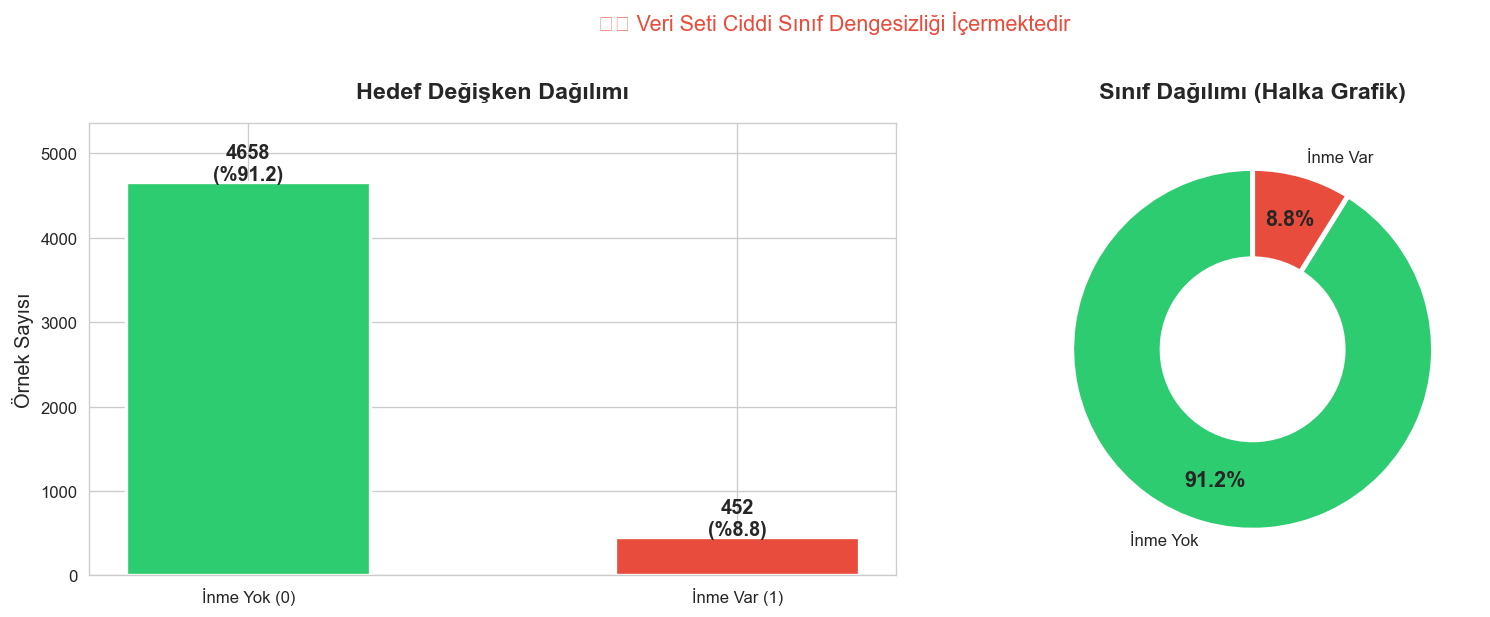


Dengesizlik Oranı: 10.3:1 (Negatif:Pozitif)


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
counts = df['stroke'].value_counts()
bars = axes[0].bar(['İnme Yok (0)', 'İnme Var (1)'], counts.values,
                    color=['#2ecc71', '#e74c3c'], width=0.5, edgecolor='white', linewidth=2)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{val}\n(%{val/len(df)*100:.1f})', ha='center', fontsize=12, fontweight='bold')
axes[0].set_title('Hedef Değişken Dağılımı', fontsize=14, fontweight='bold', pad=15)
axes[0].set_ylabel('Örnek Sayısı', fontsize=12)
axes[0].set_ylim(0, counts.max() * 1.15)

# Pie chart
wedges, texts, autotexts = axes[1].pie(
    counts.values, labels=['İnme Yok', 'İnme Var'],
    colors=['#2ecc71', '#e74c3c'], autopct='%1.1f%%',
    startangle=90, pctdistance=0.75,
    wedgeprops=dict(width=0.5, edgecolor='white', linewidth=3)
)
for autotext in autotexts:
    autotext.set_fontsize(13)
    autotext.set_fontweight('bold')
axes[1].set_title('Sınıf Dağılımı (Halka Grafik)', fontsize=14, fontweight='bold', pad=15)

plt.suptitle('⚠️ Veri Seti Ciddi Sınıf Dengesizliği İçermektedir', 
             fontsize=13, color='#e74c3c', y=1.02)
plt.tight_layout()
plt.savefig('01_hedef_dagilim.png', bbox_inches='tight', dpi=150)
plt.show()
print(f'\nDengesizlik Oranı: {counts[0]/counts[1]:.1f}:1 (Negatif:Pozitif)')

### 3.3 Sayısal Değişkenlerin Dağılımı

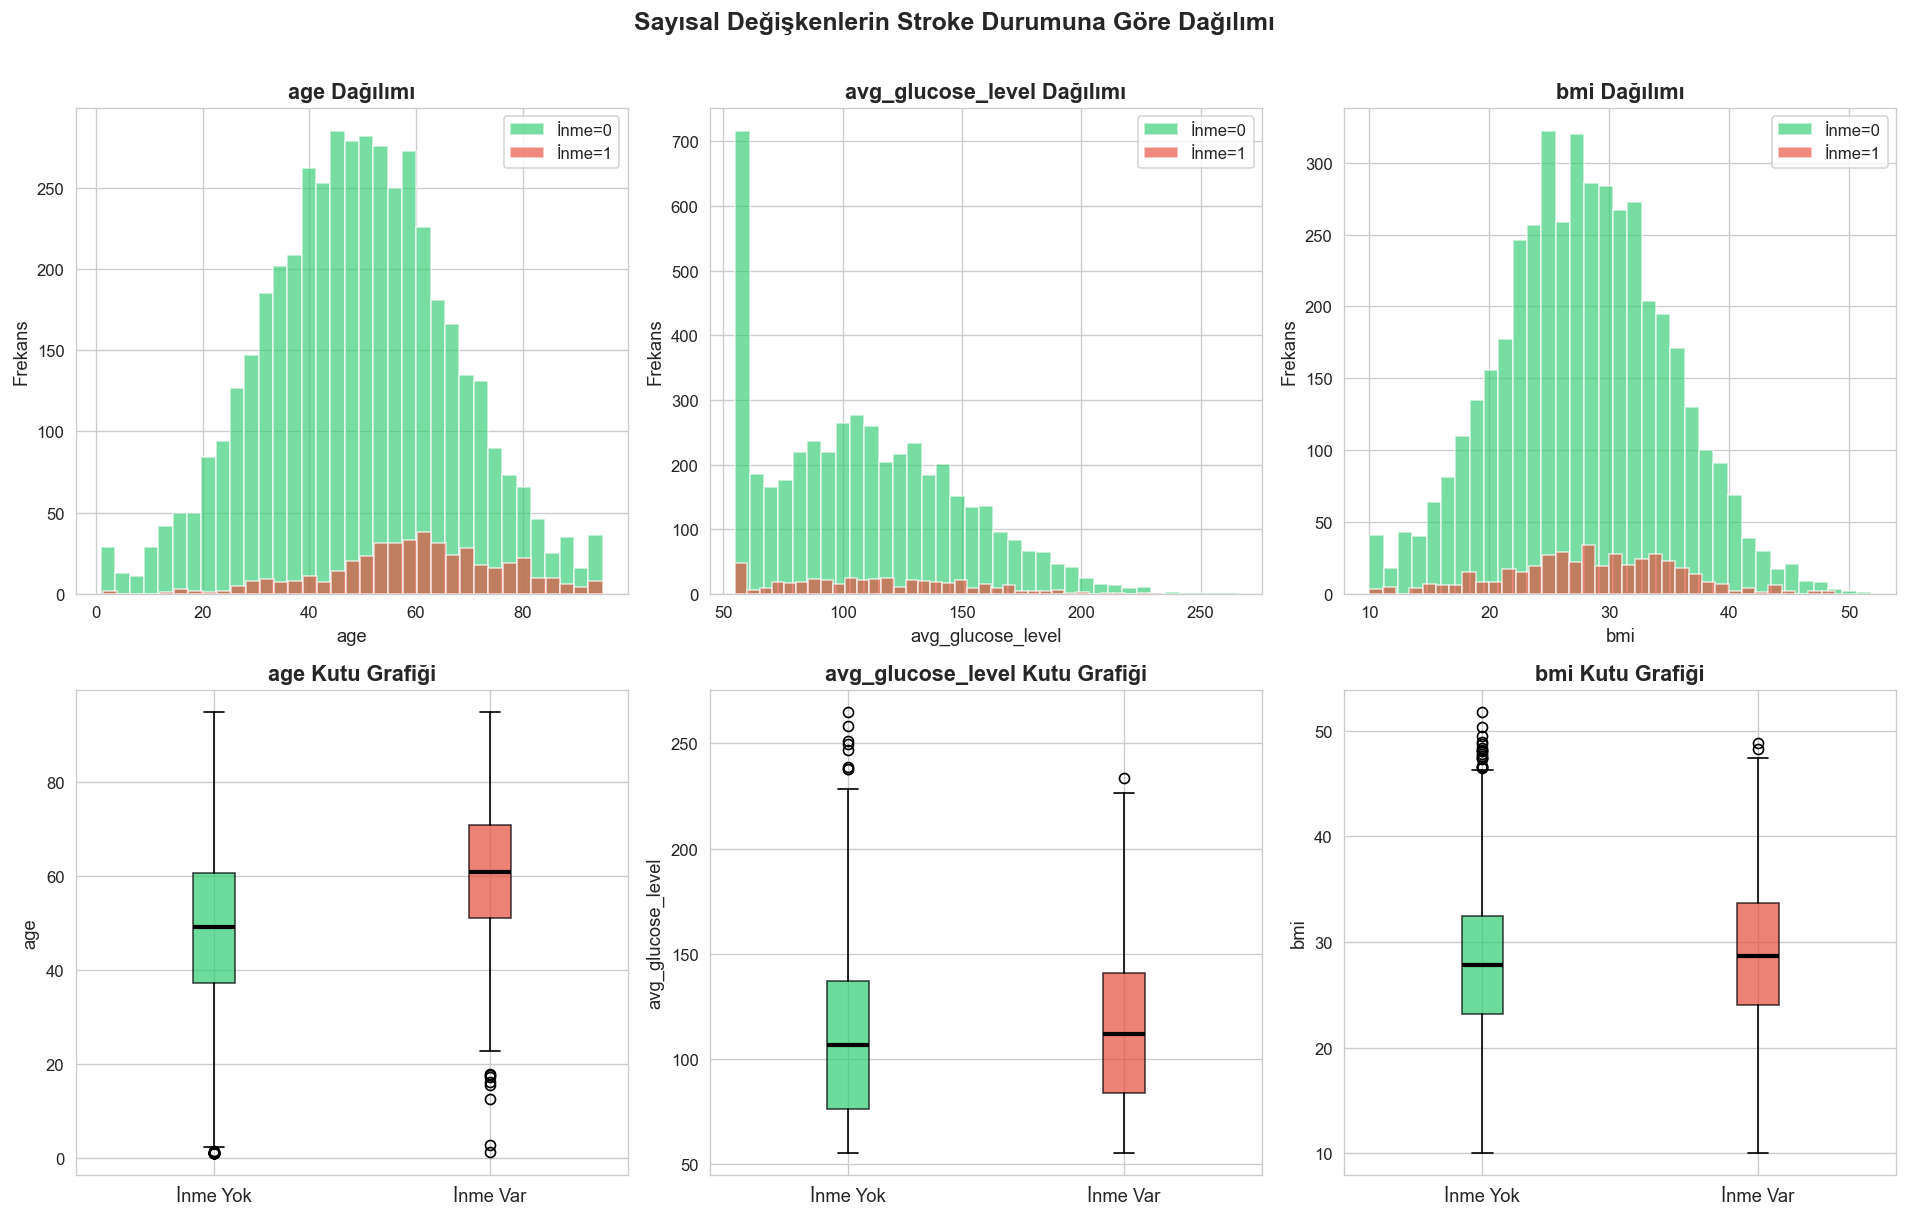

In [6]:
num_cols = ['age', 'avg_glucose_level', 'bmi']
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for i, col in enumerate(num_cols):
    # Histogram
    ax = axes[0, i]
    for label, color in [(0, '#2ecc71'), (1, '#e74c3c')]:
        data = df[df['stroke'] == label][col].dropna()
        ax.hist(data, bins=35, alpha=0.65, color=color, label=f'İnme={label}', edgecolor='white')
    ax.set_title(f'{col} Dağılımı', fontsize=13, fontweight='bold')
    ax.set_xlabel(col, fontsize=11)
    ax.set_ylabel('Frekans', fontsize=11)
    ax.legend(fontsize=10)

    # Boxplot
    ax2 = axes[1, i]
    data_0 = df[df['stroke'] == 0][col].dropna()
    data_1 = df[df['stroke'] == 1][col].dropna()
    bp = ax2.boxplot([data_0, data_1], patch_artist=True,
                      medianprops=dict(color='black', linewidth=2.5))
    bp['boxes'][0].set_facecolor('#2ecc71')
    bp['boxes'][0].set_alpha(0.7)
    bp['boxes'][1].set_facecolor('#e74c3c')
    bp['boxes'][1].set_alpha(0.7)
    ax2.set_xticklabels(['İnme Yok', 'İnme Var'], fontsize=11)
    ax2.set_title(f'{col} Kutu Grafiği', fontsize=13, fontweight='bold')
    ax2.set_ylabel(col, fontsize=11)

plt.suptitle('Sayısal Değişkenlerin Stroke Durumuna Göre Dağılımı',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('02_sayisal_dagilim.png', bbox_inches='tight', dpi=150)
plt.show()

### 3.4 Kategorik Değişkenlerin Analizi

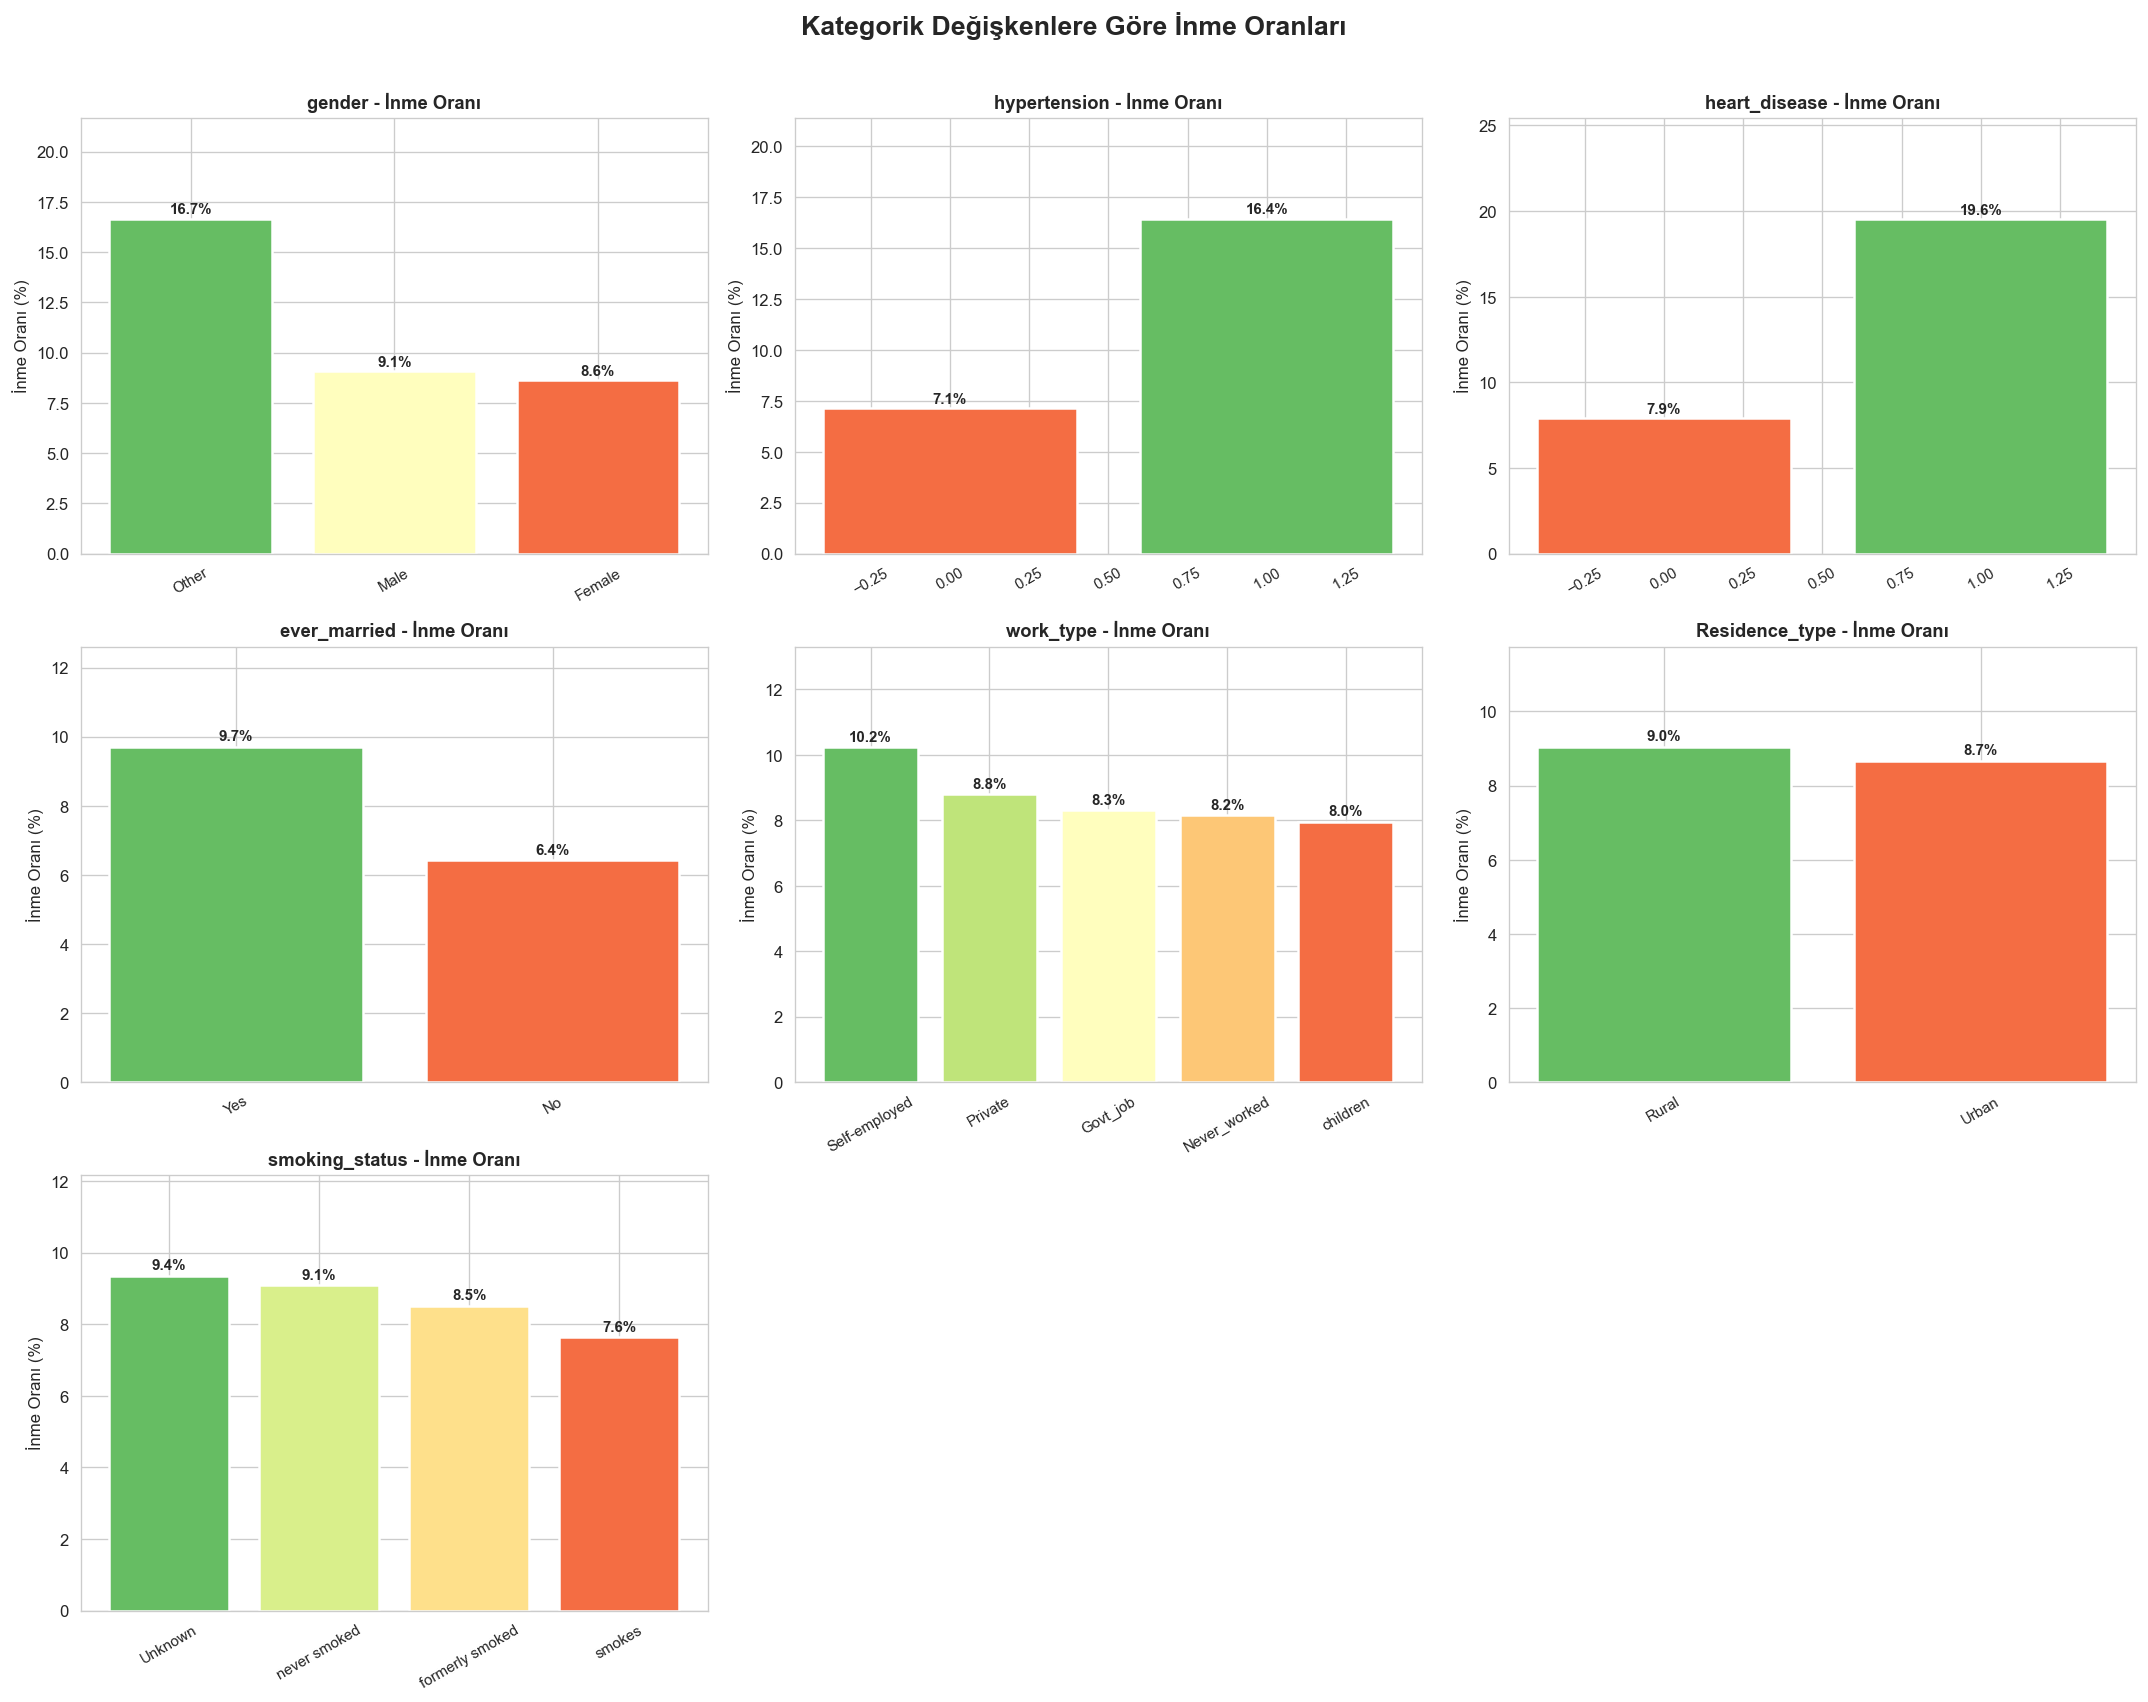

In [7]:
cat_cols = ['gender', 'hypertension', 'heart_disease', 'ever_married',
             'work_type', 'Residence_type', 'smoking_status']

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ax = axes[i]
    stroke_rate = df.groupby(col)['stroke'].mean().sort_values(ascending=False)
    colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(stroke_rate)))
    bars = ax.bar(stroke_rate.index, stroke_rate.values * 100,
                   color=colors, edgecolor='white', linewidth=1.5)
    for bar, val in zip(bars, stroke_rate.values * 100):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_title(f'{col} - İnme Oranı', fontsize=11, fontweight='bold')
    ax.set_ylabel('İnme Oranı (%)', fontsize=10)
    ax.tick_params(axis='x', rotation=30, labelsize=9)
    ax.set_ylim(0, stroke_rate.max() * 100 * 1.3)

# Boş ekseni kapat
for j in range(len(cat_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Kategorik Değişkenlere Göre İnme Oranları', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('03_kategorik_analiz.png', bbox_inches='tight', dpi=150)
plt.show()

### 3.5 Korelasyon Matrisi

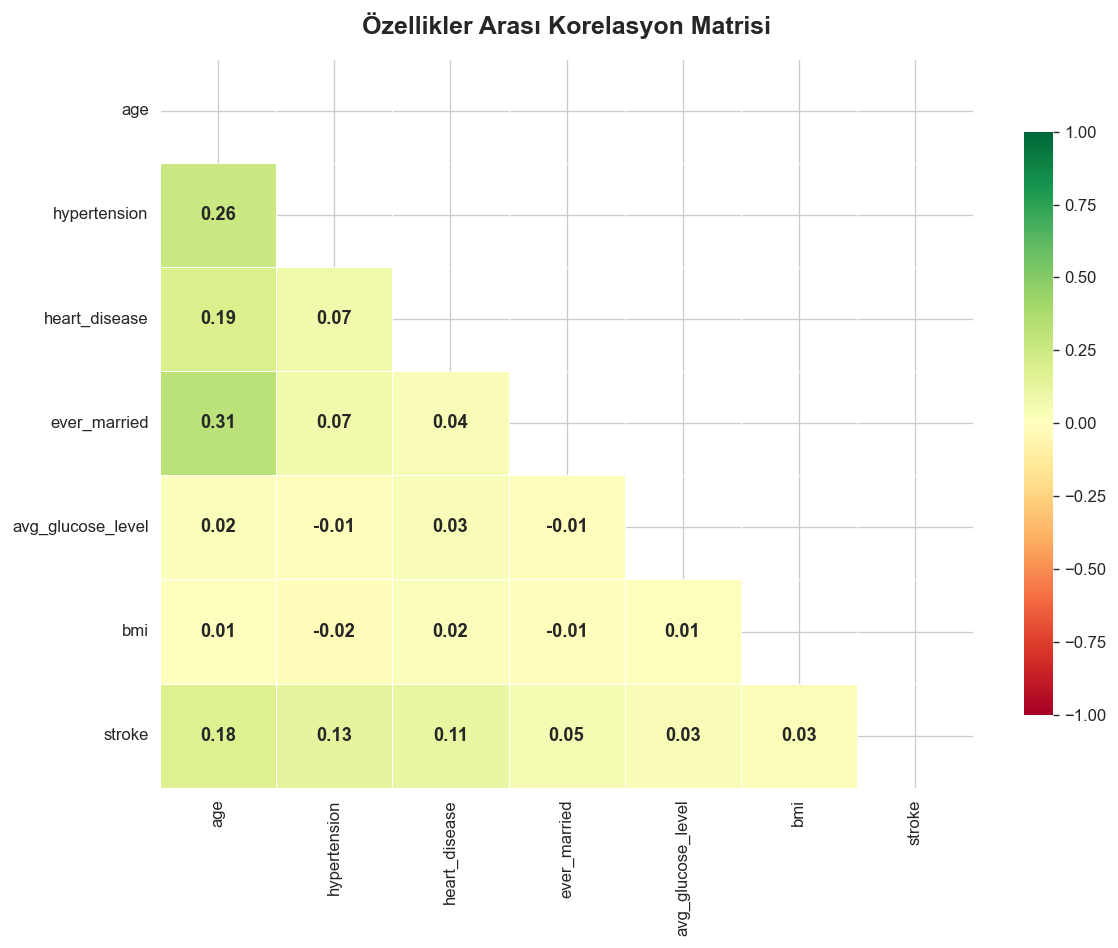

In [8]:
df_temp = df.copy()
le = LabelEncoder()
for col in ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']:
    df_temp[col] = le.fit_transform(df_temp[col].astype(str))

corr_cols = ['age', 'hypertension', 'heart_disease', 'ever_married',
              'avg_glucose_level', 'bmi', 'stroke']
corr_matrix = df_temp[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
             mask=mask, ax=ax, linewidths=0.5,
             annot_kws={'size': 11, 'weight': 'bold'},
             vmin=-1, vmax=1, center=0,
             cbar_kws={'shrink': 0.8})
ax.set_title('Özellikler Arası Korelasyon Matrisi', fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('04_korelasyon.png', bbox_inches='tight', dpi=150)
plt.show()

### 3.6 Yaş ve Glukoz Seviyesi ile İnme İlişkisi

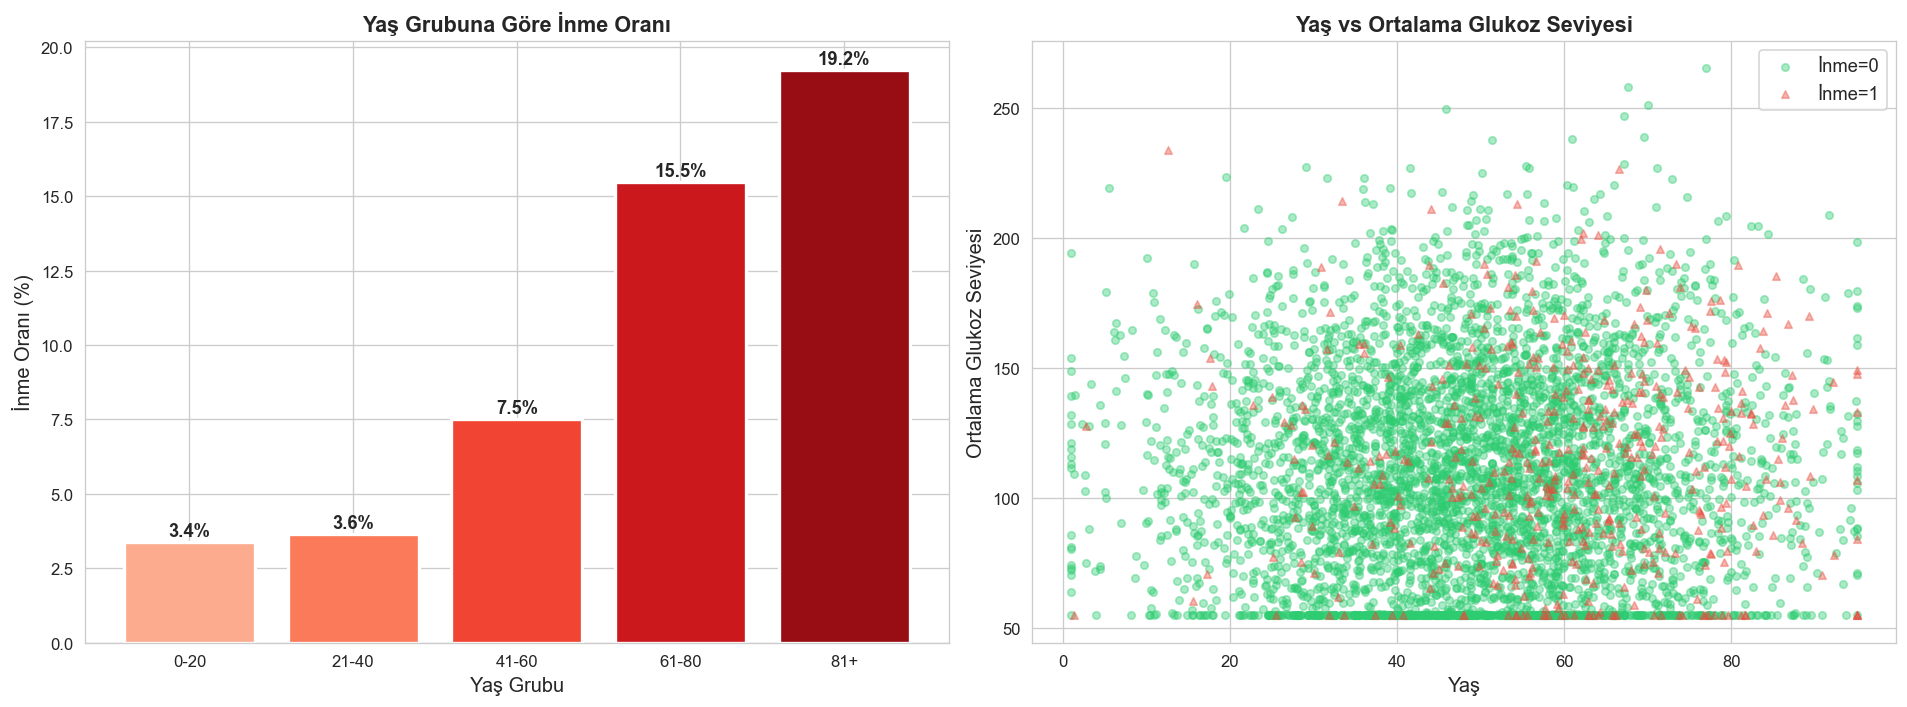

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Yaş gruplarına göre inme oranı
df['age_group'] = pd.cut(df['age'], bins=[0,20,40,60,80,100],
                           labels=['0-20','21-40','41-60','61-80','81+'])
age_stroke = df.groupby('age_group')['stroke'].mean() * 100
bars = axes[0].bar(age_stroke.index, age_stroke.values,
                    color=plt.cm.Reds(np.linspace(0.3, 0.9, len(age_stroke))),
                    edgecolor='white', linewidth=2)
for bar, val in zip(bars, age_stroke.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Yaş Grubuna Göre İnme Oranı', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Yaş Grubu', fontsize=12)
axes[0].set_ylabel('İnme Oranı (%)', fontsize=12)

# Scatter: Yaş vs Glukoz
for label, color, marker in [(0, '#2ecc71', 'o'), (1, '#e74c3c', '^')]:
    subset = df[df['stroke'] == label]
    axes[1].scatter(subset['age'], subset['avg_glucose_level'],
                     alpha=0.4, c=color, s=20, marker=marker,
                     label=f'İnme={label}')
axes[1].set_title('Yaş vs Ortalama Glukoz Seviyesi', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Yaş', fontsize=12)
axes[1].set_ylabel('Ortalama Glukoz Seviyesi', fontsize=12)
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.savefig('05_yas_glukoz.png', bbox_inches='tight', dpi=150)
plt.show()
df.drop('age_group', axis=1, inplace=True)

## 4. Veri Ön İşleme

In [10]:
print('='*60)
print('VERİ ÖN İŞLEME')
print('='*60)

df_processed = df.copy()

# 1. ID sütununu kaldır
df_processed.drop('id', axis=1, inplace=True)
print('✅ ID sütunu kaldırıldı.')

# 2. 'Other' cinsiyetli 1 satırı kaldır
df_processed = df_processed[df_processed['gender'] != 'Other']
print(f'✅ "Other" cinsiyet filtrelendi. Yeni boyut: {df_processed.shape}')

# 3. BMI eksik değerleri medyan ile doldur
bmi_median = df_processed['bmi'].median()
df_processed['bmi'].fillna(bmi_median, inplace=True)
print(f'✅ BMI eksik değerleri medyan ({bmi_median:.1f}) ile dolduruldu.')

# 4. Kategorik kodlama
le = LabelEncoder()
cat_features = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
encoding_map = {}
for col in cat_features:
    df_processed[col] = le.fit_transform(df_processed[col])
    encoding_map[col] = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f'✅ {col} kodlandı: {encoding_map[col]}')

# 5. Özellik ve hedef ayrımı
X = df_processed.drop('stroke', axis=1)
y = df_processed['stroke']

print(f'\n📊 X boyutu: {X.shape}')
print(f'📊 y dağılımı: {Counter(y)}')
print(f'\nÖzellikler: {list(X.columns)}')

VERİ ÖN İŞLEME
✅ ID sütunu kaldırıldı.
✅ "Other" cinsiyet filtrelendi. Yeni boyut: (5098, 11)
✅ BMI eksik değerleri medyan (27.9) ile dolduruldu.
✅ gender kodlandı: {'Female': np.int64(0), 'Male': np.int64(1)}
✅ ever_married kodlandı: {'No': np.int64(0), 'Yes': np.int64(1)}
✅ work_type kodlandı: {'Govt_job': np.int64(0), 'Never_worked': np.int64(1), 'Private': np.int64(2), 'Self-employed': np.int64(3), 'children': np.int64(4)}
✅ Residence_type kodlandı: {'Rural': np.int64(0), 'Urban': np.int64(1)}
✅ smoking_status kodlandı: {'Unknown': np.int64(0), 'formerly smoked': np.int64(1), 'never smoked': np.int64(2), 'smokes': np.int64(3)}

📊 X boyutu: (5098, 10)
📊 y dağılımı: Counter({0: 4648, 1: 450})

Özellikler: ['gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status']


In [11]:
# Eğitim/Test bölünmesi
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Ölçeklendirme (bazı modeller için)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

print(f'✅ Eğitim seti: {X_train.shape} | Test seti: {X_test.shape}')
print(f'Eğitim sınıf dağılımı: {Counter(y_train)}')
print(f'Test sınıf dağılımı:   {Counter(y_test)}')

✅ Eğitim seti: (4078, 10) | Test seti: (1020, 10)
Eğitim sınıf dağılımı: Counter({0: 3718, 1: 360})
Test sınıf dağılımı:   Counter({0: 930, 1: 90})


## 5. SMOTE ÖNCESİ - Kolektif Öğrenme Modelleri

> SMOTE uygulanmadan önce orijinal dengesiz veri seti üzerinde modeller eğitilecektir.

In [14]:
def evaluate_model(model, X_tr, y_tr, X_te, y_te, model_name='Model'):
    """Model değerlendirme fonksiyonu"""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1] if hasattr(model, 'predict_proba') else y_pred
    
    results = {
        'Model': model_name,
        'Accuracy': accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred, zero_division=0),
        'Recall': recall_score(y_te, y_pred, zero_division=0),
        'F1-Score': f1_score(y_te, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_te, y_prob),
        'Avg-Precision': average_precision_score(y_te, y_prob)
    }
    return results, model, y_pred, y_prob


# SMOTE ÖNCESİ MODELLER
models_before = {
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=200, learning_rate=0.05, eval_metric='logloss',
                               use_label_encoder=False, random_state=42),
    'LightGBM': LGBMClassifier(n_estimators=200, learning_rate=0.05, random_state=42, verbose=-1),
    'AdaBoost': AdaBoostClassifier(n_estimators=200, random_state=42),
    #'Bagging (DT)': BaggingClassifier(base_estimator=DecisionTreeClassifier(max_depth=5),n_estimators=100, random_state=42, n_jobs=-1)
}

results_before = []
trained_models_before = {}
preds_before = {}

print('🔄 SMOTE ÖNCESİ Model Eğitimi Başlıyor...\n')
for name, model in models_before.items():
    res, trained, y_pred, y_prob = evaluate_model(model, X_train, y_train, X_test, y_test, name)
    results_before.append(res)
    trained_models_before[name] = trained
    preds_before[name] = (y_pred, y_prob)
    print(f'✅ {name:20s} | Acc: {res["Accuracy"]:.3f} | F1: {res["F1-Score"]:.3f} | AUC: {res["ROC-AUC"]:.3f}')

df_before = pd.DataFrame(results_before)
print('\n🏆 SMOTE ÖNCESİ SONUÇLAR:')
print(df_before.set_index('Model').round(4).to_string())

🔄 SMOTE ÖNCESİ Model Eğitimi Başlıyor...

✅ Random Forest        | Acc: 0.911 | F1: 0.000 | AUC: 0.629
✅ Gradient Boosting    | Acc: 0.909 | F1: 0.000 | AUC: 0.688
✅ XGBoost              | Acc: 0.913 | F1: 0.043 | AUC: 0.636
✅ LightGBM             | Acc: 0.911 | F1: 0.022 | AUC: 0.626
✅ AdaBoost             | Acc: 0.912 | F1: 0.000 | AUC: 0.713

🏆 SMOTE ÖNCESİ SONUÇLAR:
                   Accuracy  Precision  Recall  F1-Score  ROC-AUC  Avg-Precision
Model                                                                           
Random Forest        0.9108     0.0000  0.0000    0.0000   0.6286         0.1442
Gradient Boosting    0.9088     0.0000  0.0000    0.0000   0.6877         0.1584
XGBoost              0.9127     0.6667  0.0222    0.0430   0.6355         0.1545
LightGBM             0.9108     0.3333  0.0111    0.0215   0.6260         0.1384
AdaBoost             0.9118     0.0000  0.0000    0.0000   0.7127         0.1841


## 6. SMOTE Uygulaması

**SMOTE (Synthetic Minority Oversampling Technique):** Azınlık sınıfından sentetik örnekler üretir. KNN algoritması kullanarak, mevcut azınlık örnekleri arasındaki boşluklarda yeni sentetik örnekler oluşturur.

SMOTE UYGULAMASI

📊 SMOTE Öncesi Eğitim Dağılımı: Counter({0: 3718, 1: 360})
📊 SMOTE Sonrası Eğitim Dağılımı: Counter({0: 3718, 1: 3718})

🔺 Yeni Örnek Sayısı: 3358 sentetik örnek eklendi
📈 Veri seti büyümesi: 4078 → 7436 (%82 artış)


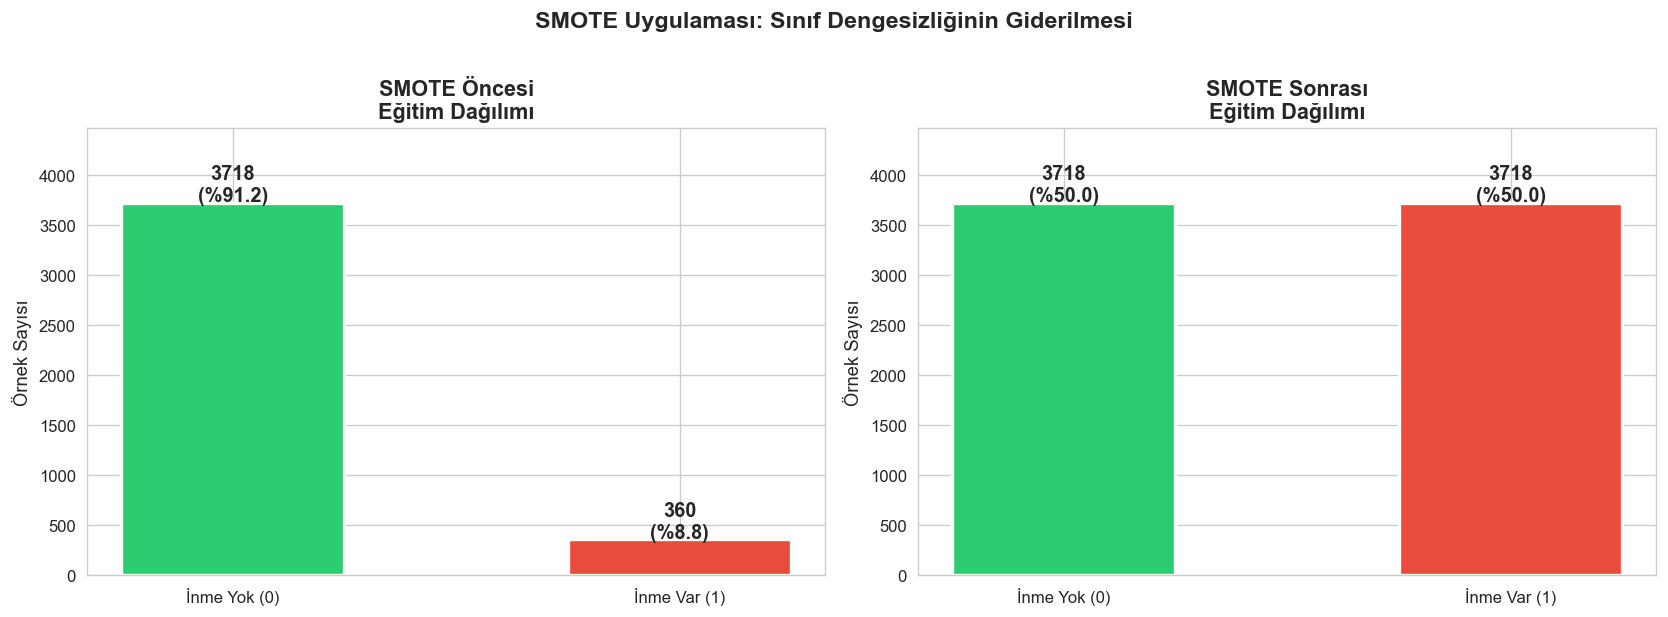

In [15]:
print('='*60)
print('SMOTE UYGULAMASI')
print('='*60)

print(f'\n📊 SMOTE Öncesi Eğitim Dağılımı: {Counter(y_train)}')

# SMOTE uygula
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f'📊 SMOTE Sonrası Eğitim Dağılımı: {Counter(y_train_smote)}')
print(f'\n🔺 Yeni Örnek Sayısı: {len(X_train_smote) - len(X_train)} sentetik örnek eklendi')
print(f'📈 Veri seti büyümesi: {len(X_train)} → {len(X_train_smote)} (%{(len(X_train_smote)/len(X_train)-1)*100:.0f} artış)')

# SMOTE görselleştirmesi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (title, y_data, color) in zip(axes, [
    ('SMOTE Öncesi\nEğitim Dağılımı', y_train, ['#2ecc71', '#e74c3c']),
    ('SMOTE Sonrası\nEğitim Dağılımı', y_train_smote, ['#2ecc71', '#e74c3c'])
]):
    cnt = Counter(y_data)
    bars = ax.bar(['İnme Yok (0)', 'İnme Var (1)'],
                   [cnt[0], cnt[1]], color=color,
                   edgecolor='white', linewidth=2, width=0.5)
    for bar, val in zip(bars, [cnt[0], cnt[1]]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
                f'{val}\n(%{val/sum(cnt.values())*100:.1f})',
                ha='center', fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('Örnek Sayısı', fontsize=11)
    ax.set_ylim(0, max(cnt[0], cnt[1]) * 1.2)

plt.suptitle('SMOTE Uygulaması: Sınıf Dengesizliğinin Giderilmesi',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('06_smote_dagilim.png', bbox_inches='tight', dpi=150)
plt.show()

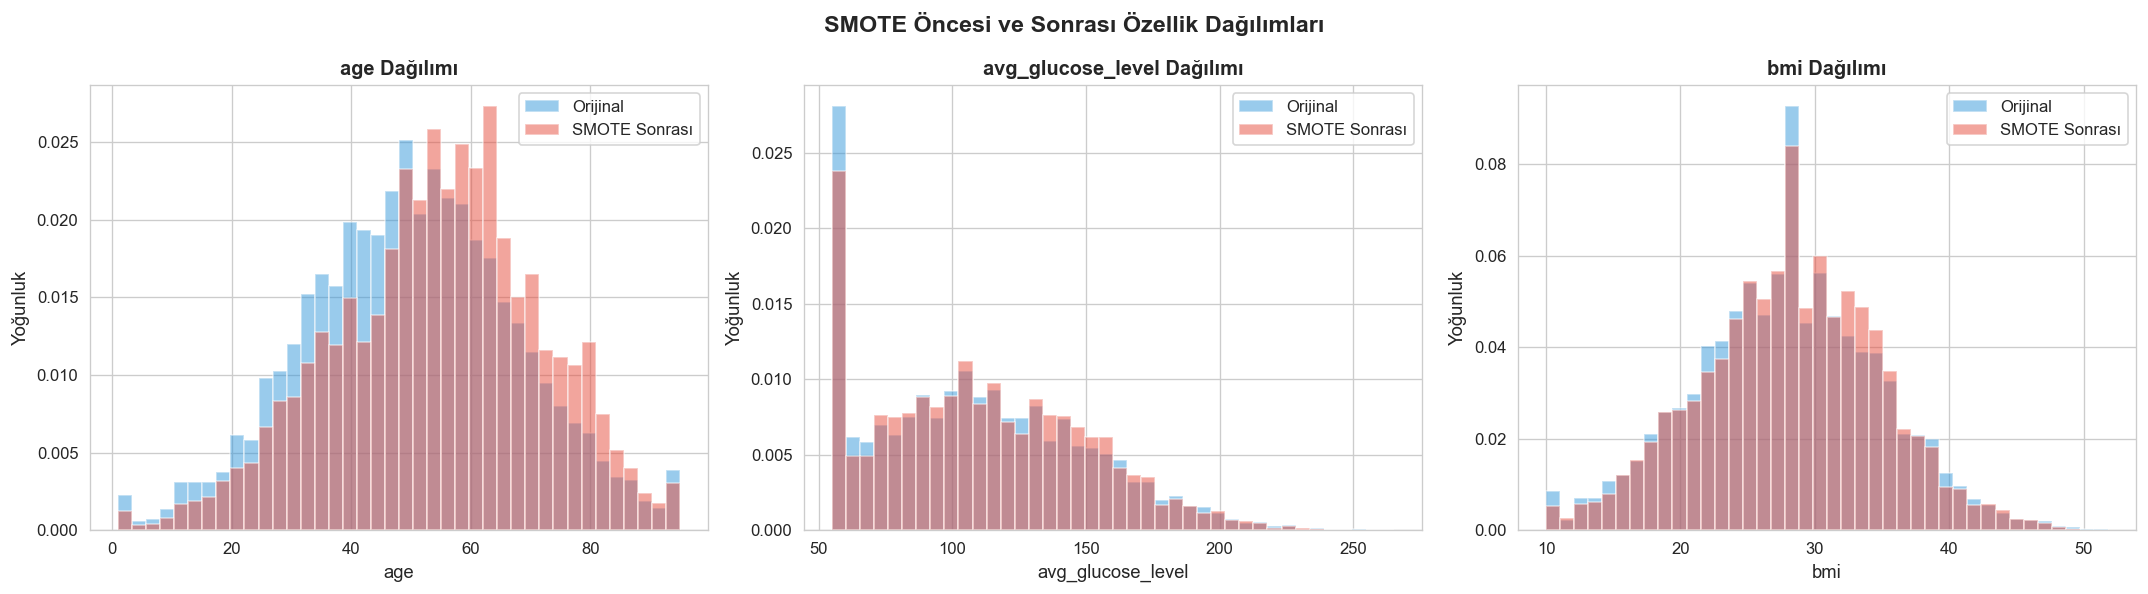

In [16]:
# SMOTE öncesi ve sonrası BMI dağılımı karşılaştırması
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
features_to_check = ['age', 'avg_glucose_level', 'bmi']

for ax, feat in zip(axes, features_to_check):
    idx = X_train.columns.get_loc(feat)
    # Orijinal
    ax.hist(X_train[feat], bins=40, alpha=0.5, color='#3498db', label='Orijinal', density=True)
    # SMOTE sonrası
    ax.hist(X_train_smote[:, idx] if isinstance(X_train_smote, np.ndarray) else X_train_smote[feat],
             bins=40, alpha=0.5, color='#e74c3c', label='SMOTE Sonrası', density=True)
    ax.set_title(f'{feat} Dağılımı', fontsize=12, fontweight='bold')
    ax.set_xlabel(feat, fontsize=11)
    ax.set_ylabel('Yoğunluk', fontsize=11)
    ax.legend(fontsize=10)

plt.suptitle('SMOTE Öncesi ve Sonrası Özellik Dağılımları',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('07_smote_ozellik.png', bbox_inches='tight', dpi=150)
plt.show()

## 7. SMOTE SONRASI - Kolektif Öğrenme Modelleri

In [18]:
# SMOTE SONRASI MODELLER
models_after = {
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=200, learning_rate=0.05, eval_metric='logloss',
                               use_label_encoder=False, random_state=42),
    'LightGBM': LGBMClassifier(n_estimators=200, learning_rate=0.05, random_state=42, verbose=-1),
    'AdaBoost': AdaBoostClassifier(n_estimators=200, random_state=42),
   # 'Bagging (DT)': BaggingClassifier(base_estimator=DecisionTreeClassifier(max_depth=5),
   #                                     n_estimators=100, random_state=42, n_jobs=-1)
}

results_after = []
trained_models_after = {}
preds_after = {}

print('🔄 SMOTE SONRASI Model Eğitimi Başlıyor...\n')
for name, model in models_after.items():
    res, trained, y_pred, y_prob = evaluate_model(model, X_train_smote, y_train_smote, X_test, y_test, name)
    results_after.append(res)
    trained_models_after[name] = trained
    preds_after[name] = (y_pred, y_prob)
    print(f'✅ {name:20s} | Acc: {res["Accuracy"]:.3f} | F1: {res["F1-Score"]:.3f} | AUC: {res["ROC-AUC"]:.3f}')

df_after = pd.DataFrame(results_after)
print('\n🏆 SMOTE SONRASI SONUÇLAR:')
print(df_after.set_index('Model').round(4).to_string())

🔄 SMOTE SONRASI Model Eğitimi Başlıyor...

✅ Random Forest        | Acc: 0.811 | F1: 0.111 | AUC: 0.612
✅ Gradient Boosting    | Acc: 0.721 | F1: 0.169 | AUC: 0.581
✅ XGBoost              | Acc: 0.771 | F1: 0.182 | AUC: 0.581
✅ LightGBM             | Acc: 0.790 | F1: 0.171 | AUC: 0.563
✅ AdaBoost             | Acc: 0.696 | F1: 0.188 | AUC: 0.599

🏆 SMOTE SONRASI SONUÇLAR:
                   Accuracy  Precision  Recall  F1-Score  ROC-AUC  Avg-Precision
Model                                                                           
Random Forest        0.8108     0.0945  0.1333    0.1106   0.6124         0.1106
Gradient Boosting    0.7206     0.1146  0.3222    0.1691   0.5805         0.1135
XGBoost              0.7706     0.1327  0.2889    0.1818   0.5808         0.1101
LightGBM             0.7902     0.1310  0.2444    0.1705   0.5630         0.1060
AdaBoost             0.6961     0.1233  0.4000    0.1885   0.5985         0.1126


## 8. SMOTE Öncesi vs Sonrası Karşılaştırması

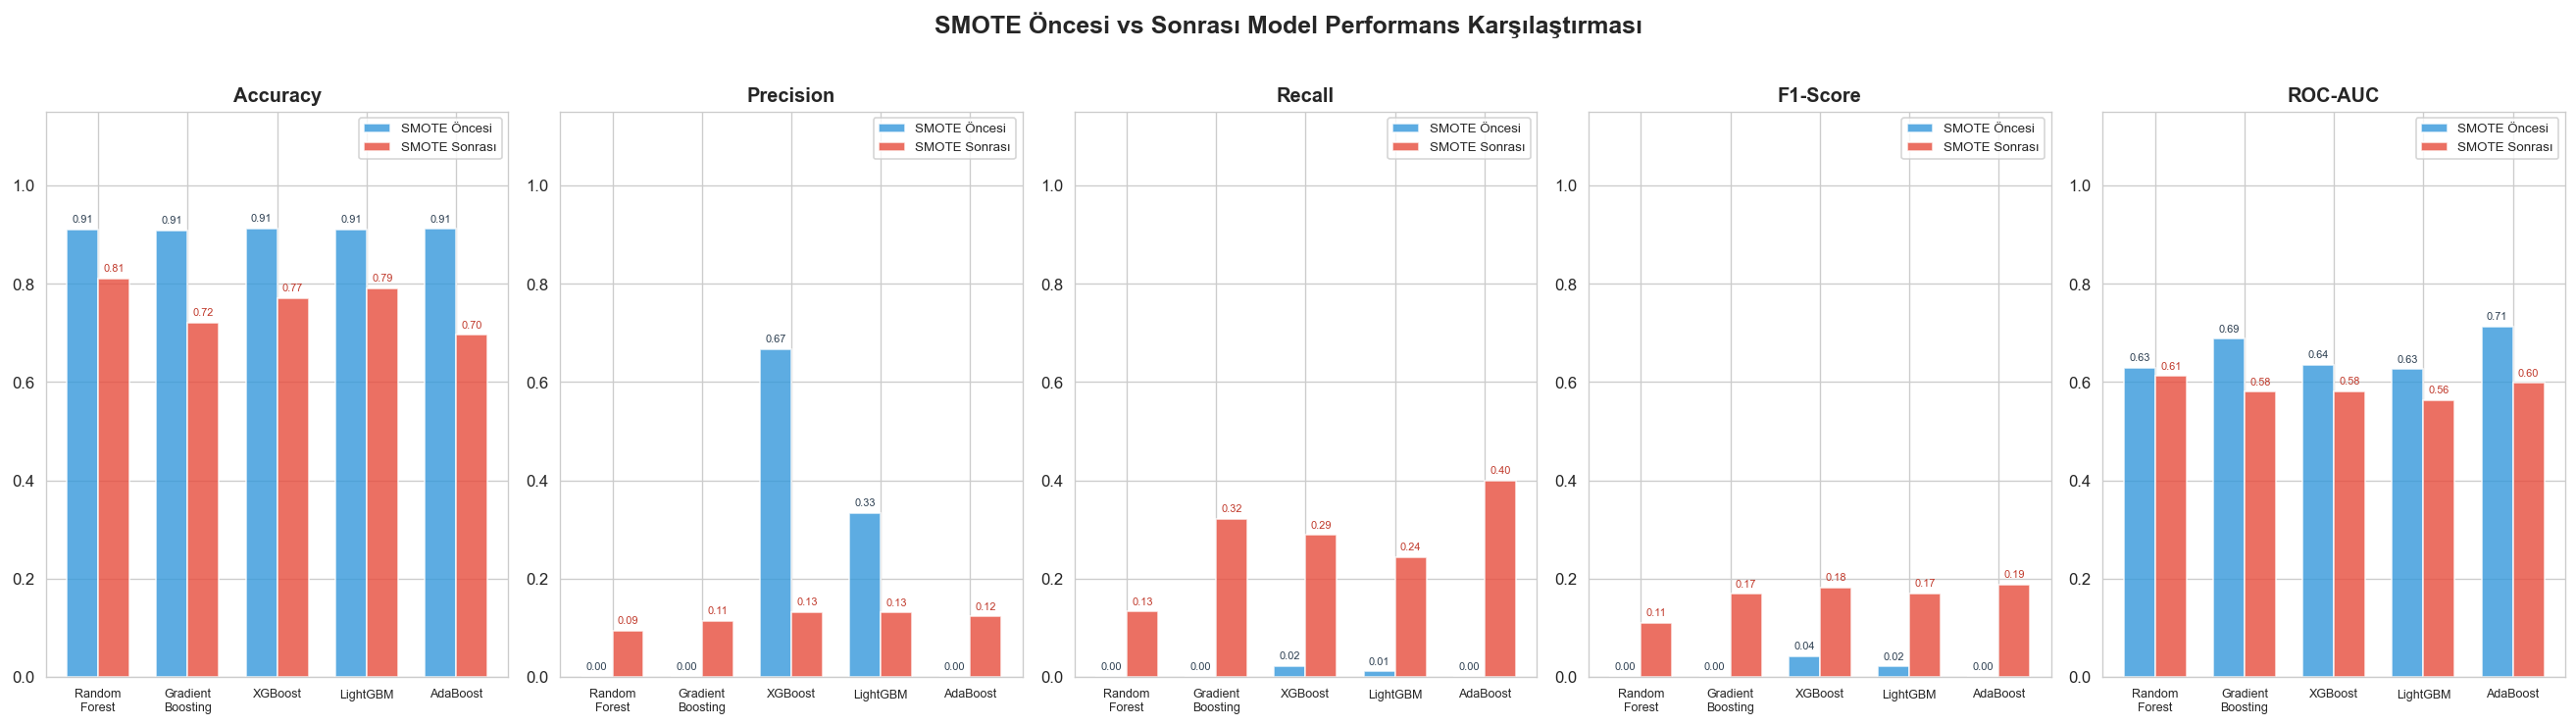

In [19]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
model_names = df_before['Model'].tolist()
n_models = len(model_names)
n_metrics = len(metrics)

fig, axes = plt.subplots(1, n_metrics, figsize=(22, 6))

x = np.arange(n_models)
width = 0.35

for i, (ax, metric) in enumerate(zip(axes, metrics)):
    vals_before = df_before[metric].values
    vals_after = df_after[metric].values
    
    bars1 = ax.bar(x - width/2, vals_before, width, label='SMOTE Öncesi',
                    color='#3498db', alpha=0.8, edgecolor='white')
    bars2 = ax.bar(x + width/2, vals_after, width, label='SMOTE Sonrası',
                    color='#e74c3c', alpha=0.8, edgecolor='white')
    
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([m.replace(' ', '\n') for m in model_names], fontsize=7.5)
    ax.set_ylim(0, 1.15)
    ax.legend(fontsize=8)
    
    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=6.5, color='#2c3e50')
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=6.5, color='#c0392b')

plt.suptitle('SMOTE Öncesi vs Sonrası Model Performans Karşılaştırması',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('08_smote_karsilastirma.png', bbox_inches='tight', dpi=150)
plt.show()

In [20]:
# İyileşme tablosu
improvement = df_after.set_index('Model')[metrics] - df_before.set_index('Model')[metrics]
print('📊 SMOTE Sonrası Metrik İyileşmeleri (Δ = Sonrası - Öncesi):')
print('='*70)

styled = improvement.round(4)
for col in styled.columns:
    styled[col] = styled[col].apply(lambda x: f'+{x:.4f}' if x > 0 else f'{x:.4f}')
print(styled.to_string())

print('\n💡 Ortalama İyileşme:')
avg_imp = improvement.mean()
for metric, val in avg_imp.items():
    arrow = '↑' if val > 0 else '↓'
    print(f'  {metric:15s}: {arrow} {val:+.4f}')

📊 SMOTE Sonrası Metrik İyileşmeleri (Δ = Sonrası - Öncesi):
                  Accuracy Precision   Recall F1-Score  ROC-AUC
Model                                                          
Random Forest      -0.1000   +0.0945  +0.1333  +0.1106  -0.0162
Gradient Boosting  -0.1882   +0.1146  +0.3222  +0.1691  -0.1072
XGBoost            -0.1422   -0.5340  +0.2667  +0.1388  -0.0547
LightGBM           -0.1206   -0.2024  +0.2333  +0.1490  -0.0630
AdaBoost           -0.2157   +0.1233  +0.4000  +0.1885  -0.1142

💡 Ortalama İyileşme:
  Accuracy       : ↓ -0.1533
  Precision      : ↓ -0.0808
  Recall         : ↑ +0.2711
  F1-Score       : ↑ +0.1512
  ROC-AUC        : ↓ -0.0710


## 9. ROC Eğrisi Analizi

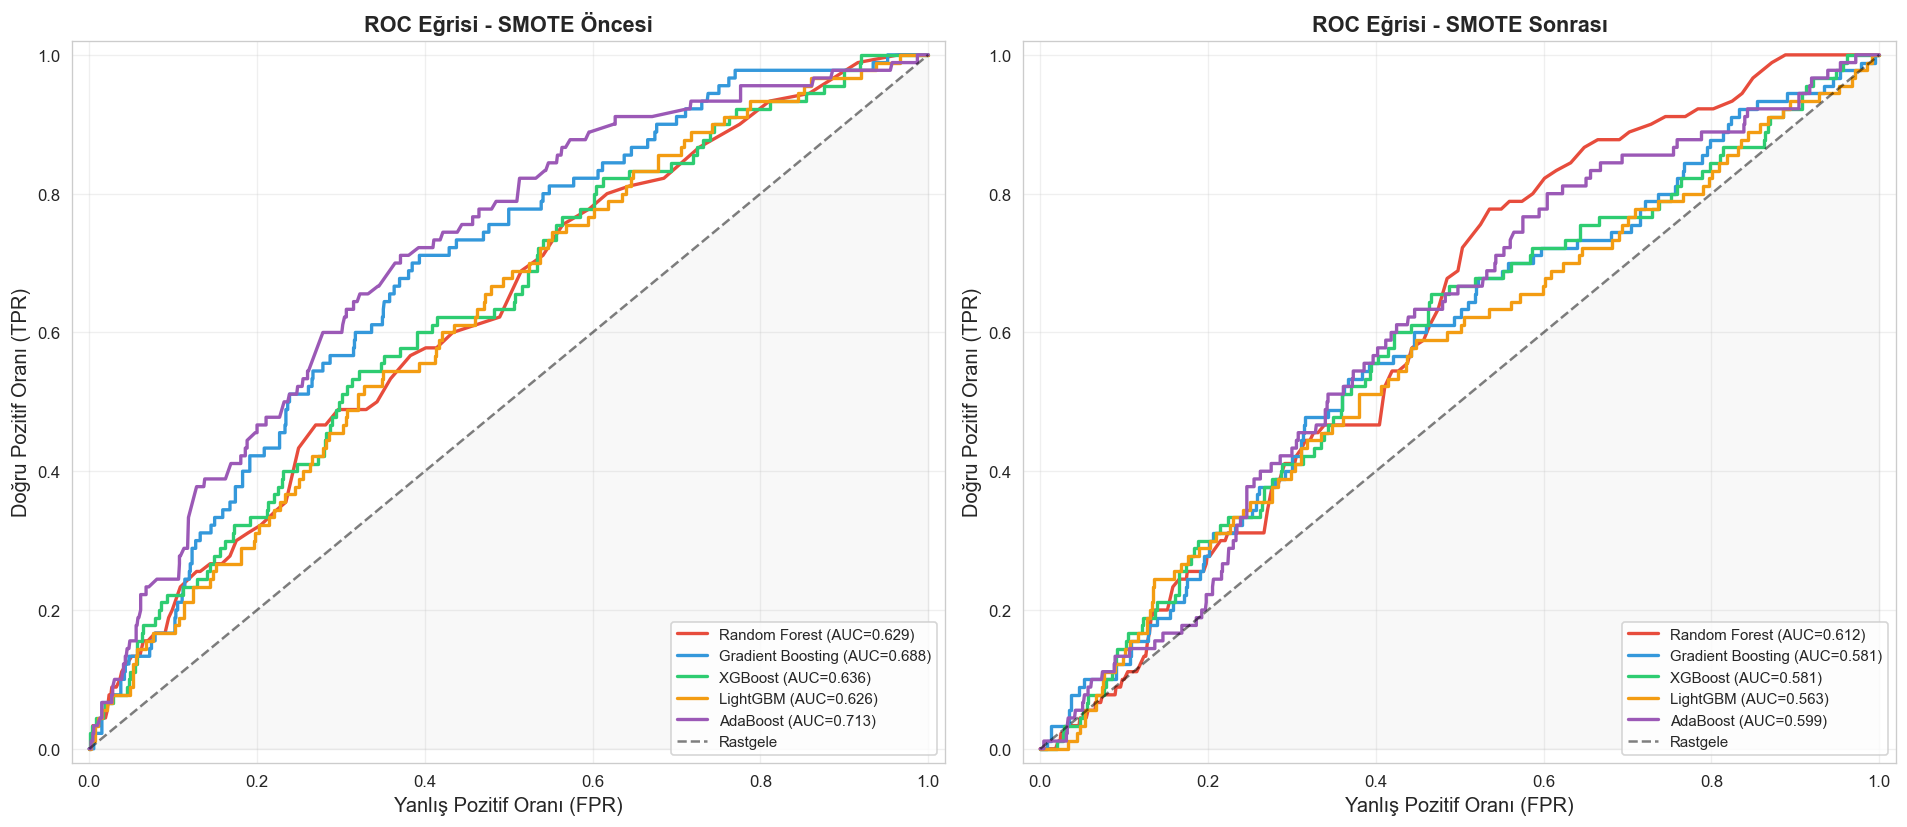

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
colors_roc = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']

for ax, (title, preds_dict) in zip(axes, [
    ('SMOTE Öncesi', preds_before),
    ('SMOTE Sonrası', preds_after)
]):
    for (name, (_, y_prob)), color in zip(preds_dict.items(), colors_roc):
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        auc_val = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc_val:.3f})')
    
    ax.plot([0,1], [0,1], 'k--', lw=1.5, alpha=0.5, label='Rastgele')
    ax.fill_between([0,1], [0,1], alpha=0.05, color='gray')
    ax.set_xlim([-0.02, 1.02])
    ax.set_ylim([-0.02, 1.02])
    ax.set_xlabel('Yanlış Pozitif Oranı (FPR)', fontsize=12)
    ax.set_ylabel('Doğru Pozitif Oranı (TPR)', fontsize=12)
    ax.set_title(f'ROC Eğrisi - {title}', fontsize=13, fontweight='bold')
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('09_roc_egrisi.png', bbox_inches='tight', dpi=150)
plt.show()

## 10. Karışıklık Matrisleri - En İyi Model (SMOTE Sonrası XGBoost)

🏆 En İyi Model (F1-Score): AdaBoost


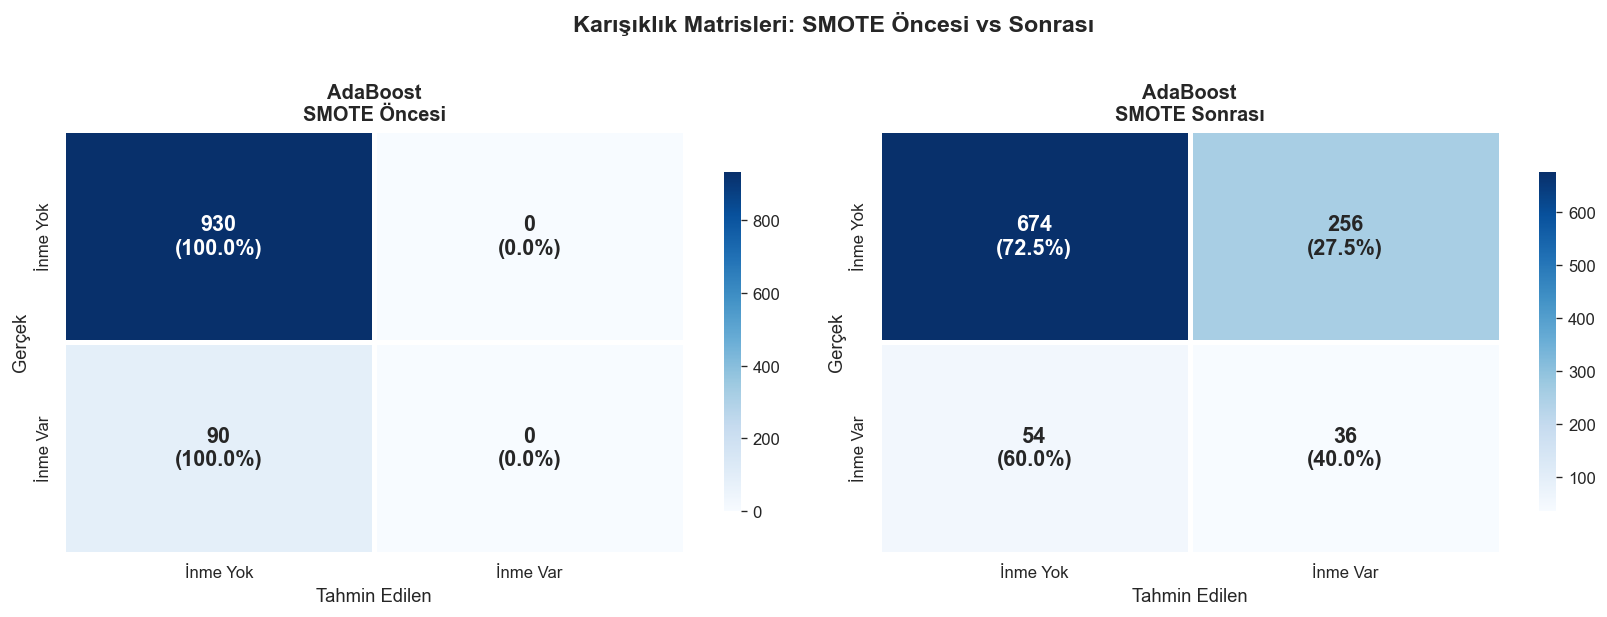


📋 AdaBoost - SMOTE Sonrası Detaylı Rapor:
              precision    recall  f1-score   support

    İnme Yok       0.93      0.72      0.81       930
    İnme Var       0.12      0.40      0.19        90

    accuracy                           0.70      1020
   macro avg       0.52      0.56      0.50      1020
weighted avg       0.86      0.70      0.76      1020



In [22]:
# En iyi model: F1-Score'a göre SMOTE sonrası XGBoost
best_model_name = df_after.loc[df_after['F1-Score'].idxmax(), 'Model']
print(f'🏆 En İyi Model (F1-Score): {best_model_name}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (title, preds_dict) in zip(axes, [
    ('SMOTE Öncesi', preds_before),
    ('SMOTE Sonrası', preds_after)
]):
    y_pred_best = preds_dict[best_model_name][0]
    cm = confusion_matrix(y_test, y_pred_best)
    
    # Normalize
    cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100
    
    labels = [[f'{cm[i,j]}\n({cm_pct[i,j]:.1f}%)' for j in range(2)] for i in range(2)]
    
    sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', ax=ax,
                xticklabels=['İnme Yok', 'İnme Var'],
                yticklabels=['İnme Yok', 'İnme Var'],
                linewidths=2, linecolor='white',
                annot_kws={'size': 13, 'weight': 'bold'},
                cbar_kws={'shrink': 0.8})
    ax.set_title(f'{best_model_name}\n{title}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Tahmin Edilen', fontsize=11)
    ax.set_ylabel('Gerçek', fontsize=11)

plt.suptitle('Karışıklık Matrisleri: SMOTE Öncesi vs Sonrası',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('10_confusion_matrix.png', bbox_inches='tight', dpi=150)
plt.show()

print(f'\n📋 {best_model_name} - SMOTE Sonrası Detaylı Rapor:')
print(classification_report(y_test, preds_after[best_model_name][0],
                              target_names=['İnme Yok', 'İnme Var']))

## 11. SHAP Analizi - Model Yorumlanabilirliği

**SHAP (SHapley Additive exPlanations):** Her özelliğin model çıktısına katkısını hesaplamak için oyun teorisinden yararlanır.

In [23]:
print('🔄 SHAP değerleri hesaplanıyor... (Bu işlem birkaç dakika sürebilir)')

# En iyi model (XGBoost SMOTE sonrası)
best_model = trained_models_after.get('XGBoost', trained_models_after[best_model_name])

# SHAP Explainer
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

print(f'✅ SHAP değerleri hesaplandı! Shape: {np.array(shap_values).shape}')

🔄 SHAP değerleri hesaplanıyor... (Bu işlem birkaç dakika sürebilir)
✅ SHAP değerleri hesaplandı! Shape: (1020, 10)


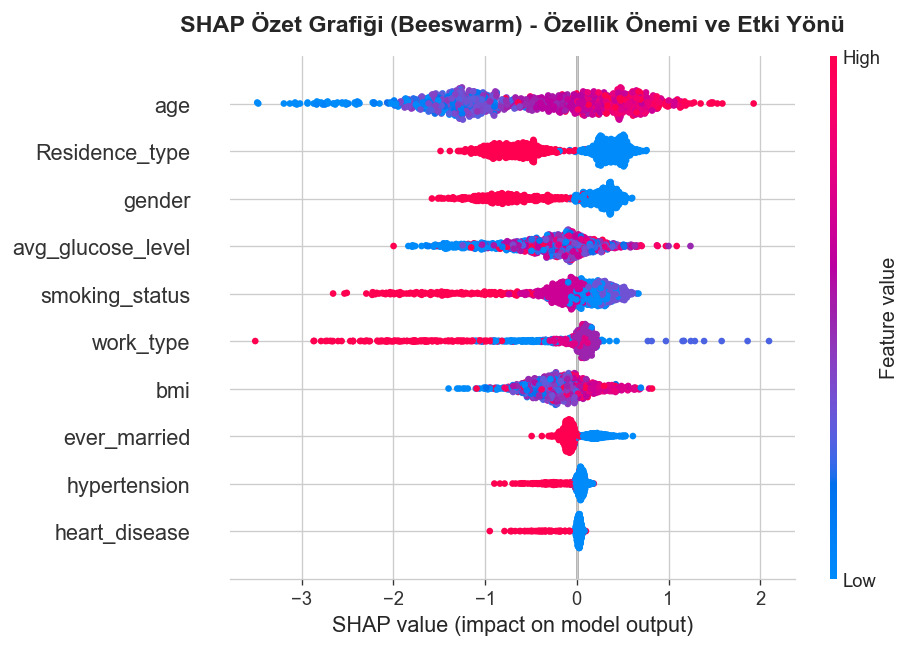


💡 Kırmızı = Yüksek değer, Mavi = Düşük değer | Sağa yatay = Pozitif etki (İnme riski artırır)


In [24]:
# 11.1 SHAP Summary Plot (Beeswarm)
plt.figure(figsize=(12, 7))
shap.summary_plot(
    shap_values, X_test,
    feature_names=X_test.columns.tolist(),
    show=False,
    max_display=10
)
plt.title('SHAP Özet Grafiği (Beeswarm) - Özellik Önemi ve Etki Yönü',
           fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('11_shap_beeswarm.png', bbox_inches='tight', dpi=150)
plt.show()
print('\n💡 Kırmızı = Yüksek değer, Mavi = Düşük değer | Sağa yatay = Pozitif etki (İnme riski artırır)')

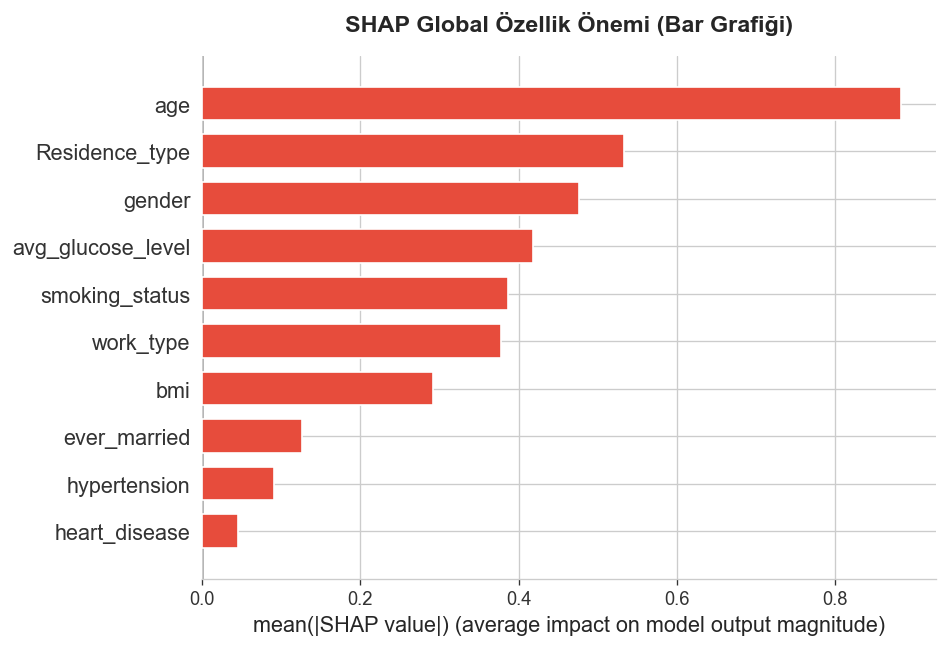

In [25]:
# 11.2 SHAP Bar Plot - Global Özellik Önemi
plt.figure(figsize=(11, 6))
shap.summary_plot(
    shap_values, X_test,
    feature_names=X_test.columns.tolist(),
    plot_type='bar',
    show=False,
    max_display=10,
    color='#e74c3c'
)
plt.title('SHAP Global Özellik Önemi (Bar Grafiği)',
           fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('12_shap_bar.png', bbox_inches='tight', dpi=150)
plt.show()

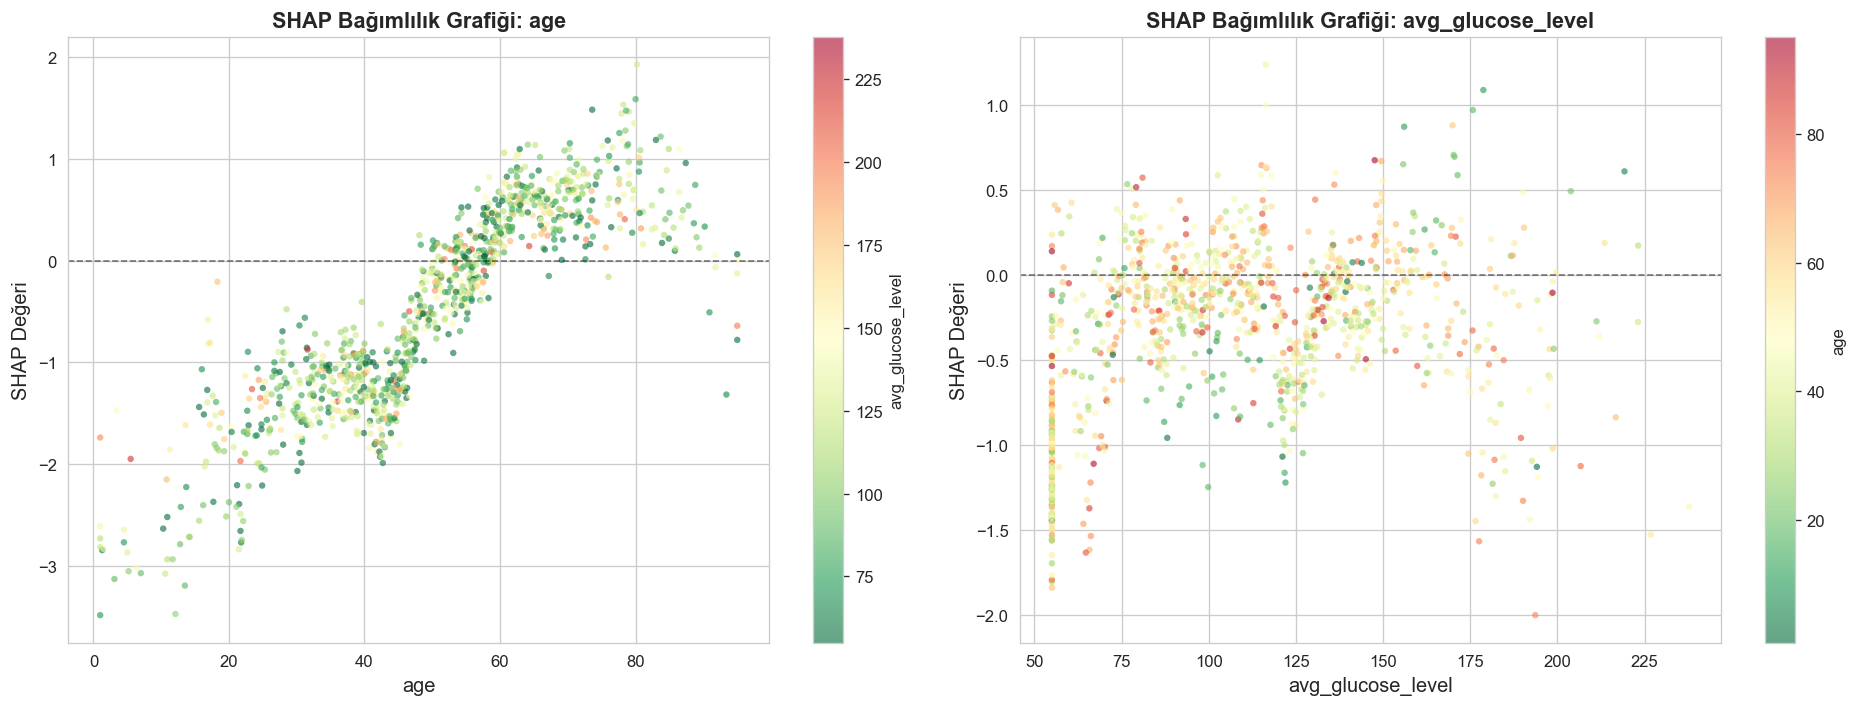

In [26]:
# 11.3 SHAP Dependence Plot - Yaş ve Glukoz
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, feature in zip(axes, ['age', 'avg_glucose_level']):
    feat_idx = list(X_test.columns).index(feature)
    sc = ax.scatter(
        X_test[feature].values,
        shap_values[:, feat_idx],
        c=X_test['age'].values if feature != 'age' else X_test['avg_glucose_level'].values,
        cmap='RdYlGn_r', alpha=0.6, s=15, edgecolors='none'
    )
    plt.colorbar(sc, ax=ax, label='age' if feature != 'age' else 'avg_glucose_level')
    ax.axhline(0, color='black', lw=1, linestyle='--', alpha=0.5)
    ax.set_xlabel(feature, fontsize=12)
    ax.set_ylabel('SHAP Değeri', fontsize=12)
    ax.set_title(f'SHAP Bağımlılık Grafiği: {feature}', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('13_shap_dependence.png', bbox_inches='tight', dpi=150)
plt.show()

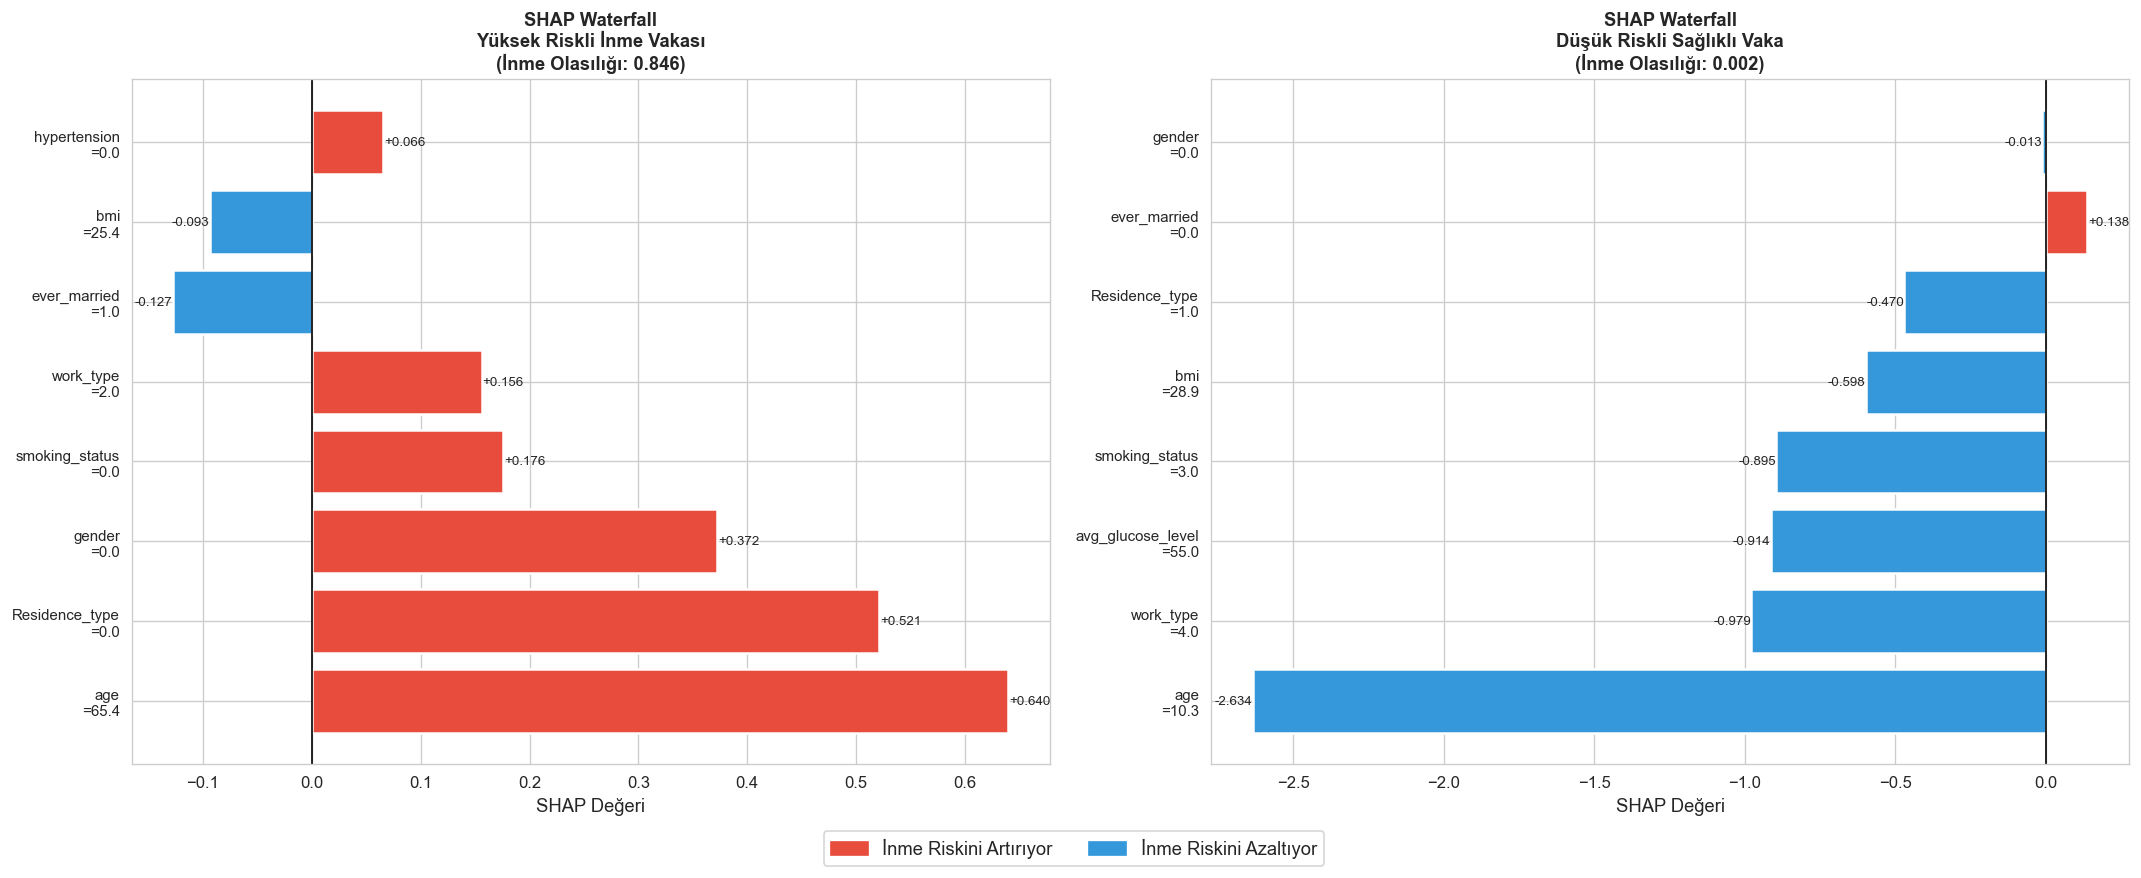

In [27]:
# 11.4 SHAP Waterfall Plot - Bireysel Tahmin Açıklaması
# İnme olan ve olmayan en yüksek güvenlikli tahminler
y_prob_test = preds_after.get('XGBoost', preds_after[best_model_name])[1]
stroke_idx = np.where(y_test.values == 1)[0]
no_stroke_idx = np.where(y_test.values == 0)[0]

# En yüksek riskli inme vakası
high_risk_idx = stroke_idx[np.argmax(y_prob_test[stroke_idx])]
# En düşük riskli sağlıklı vaka
low_risk_idx = no_stroke_idx[np.argmin(y_prob_test[no_stroke_idx])]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, idx, title_suffix in zip(axes,
                                    [high_risk_idx, low_risk_idx],
                                    ['Yüksek Riskli İnme Vakası', 'Düşük Riskli Sağlıklı Vaka']):
    shap_vals_single = shap_values[idx]
    feature_vals = X_test.iloc[idx].values
    feature_names = X_test.columns.tolist()
    base_val = explainer.expected_value
    
    # Manuel waterfall
    sorted_idx = np.argsort(np.abs(shap_vals_single))[::-1][:8]
    sorted_shap = shap_vals_single[sorted_idx]
    sorted_names = [f'{feature_names[i]}\n={feature_vals[i]:.1f}' for i in sorted_idx]
    
    colors_wf = ['#e74c3c' if v > 0 else '#3498db' for v in sorted_shap]
    bars = ax.barh(range(len(sorted_shap)), sorted_shap,
                    color=colors_wf, edgecolor='white', linewidth=1.5)
    ax.set_yticks(range(len(sorted_shap)))
    ax.set_yticklabels(sorted_names, fontsize=9)
    ax.axvline(0, color='black', lw=1)
    ax.set_xlabel('SHAP Değeri', fontsize=11)
    ax.set_title(f'SHAP Waterfall\n{title_suffix}\n(İnme Olasılığı: {y_prob_test[idx]:.3f})',
                  fontsize=11, fontweight='bold')
    
    for bar, val in zip(bars, sorted_shap):
        ax.text(val + (0.001 if val >= 0 else -0.001),
                bar.get_y() + bar.get_height()/2,
                f'{val:+.3f}', va='center',
                ha='left' if val >= 0 else 'right', fontsize=8)

red_patch = mpatches.Patch(color='#e74c3c', label='İnme Riskini Artırıyor')
blue_patch = mpatches.Patch(color='#3498db', label='İnme Riskini Azaltıyor')
fig.legend(handles=[red_patch, blue_patch], loc='lower center', ncol=2,
            fontsize=11, bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
plt.savefig('14_shap_waterfall.png', bbox_inches='tight', dpi=150)
plt.show()

## 12. Voting Classifier - Meta-Ensemble

In [28]:
# Soft Voting - En iyi 3 modeli birleştir
print('🔄 Voting Classifier eğitiliyor...')

voting_clf = VotingClassifier(
    estimators=[
        ('rf', RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)),
        ('xgb', XGBClassifier(n_estimators=200, learning_rate=0.05, eval_metric='logloss',
                               use_label_encoder=False, random_state=42)),
        ('lgbm', LGBMClassifier(n_estimators=200, learning_rate=0.05, random_state=42, verbose=-1))
    ],
    voting='soft'
)

voting_clf.fit(X_train_smote, y_train_smote)
y_pred_voting = voting_clf.predict(X_test)
y_prob_voting = voting_clf.predict_proba(X_test)[:, 1]

voting_results = {
    'Model': 'Voting Classifier\n(RF+XGB+LGBM)',
    'Accuracy': accuracy_score(y_test, y_pred_voting),
    'Precision': precision_score(y_test, y_pred_voting, zero_division=0),
    'Recall': recall_score(y_test, y_pred_voting, zero_division=0),
    'F1-Score': f1_score(y_test, y_pred_voting, zero_division=0),
    'ROC-AUC': roc_auc_score(y_test, y_prob_voting),
    'Avg-Precision': average_precision_score(y_test, y_prob_voting)
}

print('\n🏆 Voting Classifier Sonuçları:')
for k, v in voting_results.items():
    if k != 'Model':
        print(f'  {k:20s}: {v:.4f}')

🔄 Voting Classifier eğitiliyor...

🏆 Voting Classifier Sonuçları:
  Accuracy            : 0.7922
  Precision           : 0.1280
  Recall              : 0.2333
  F1-Score            : 0.1654
  ROC-AUC             : 0.5942
  Avg-Precision       : 0.1101


## 13. Kapsamlı Sonuç Tablosu ve Final Karşılaştırma

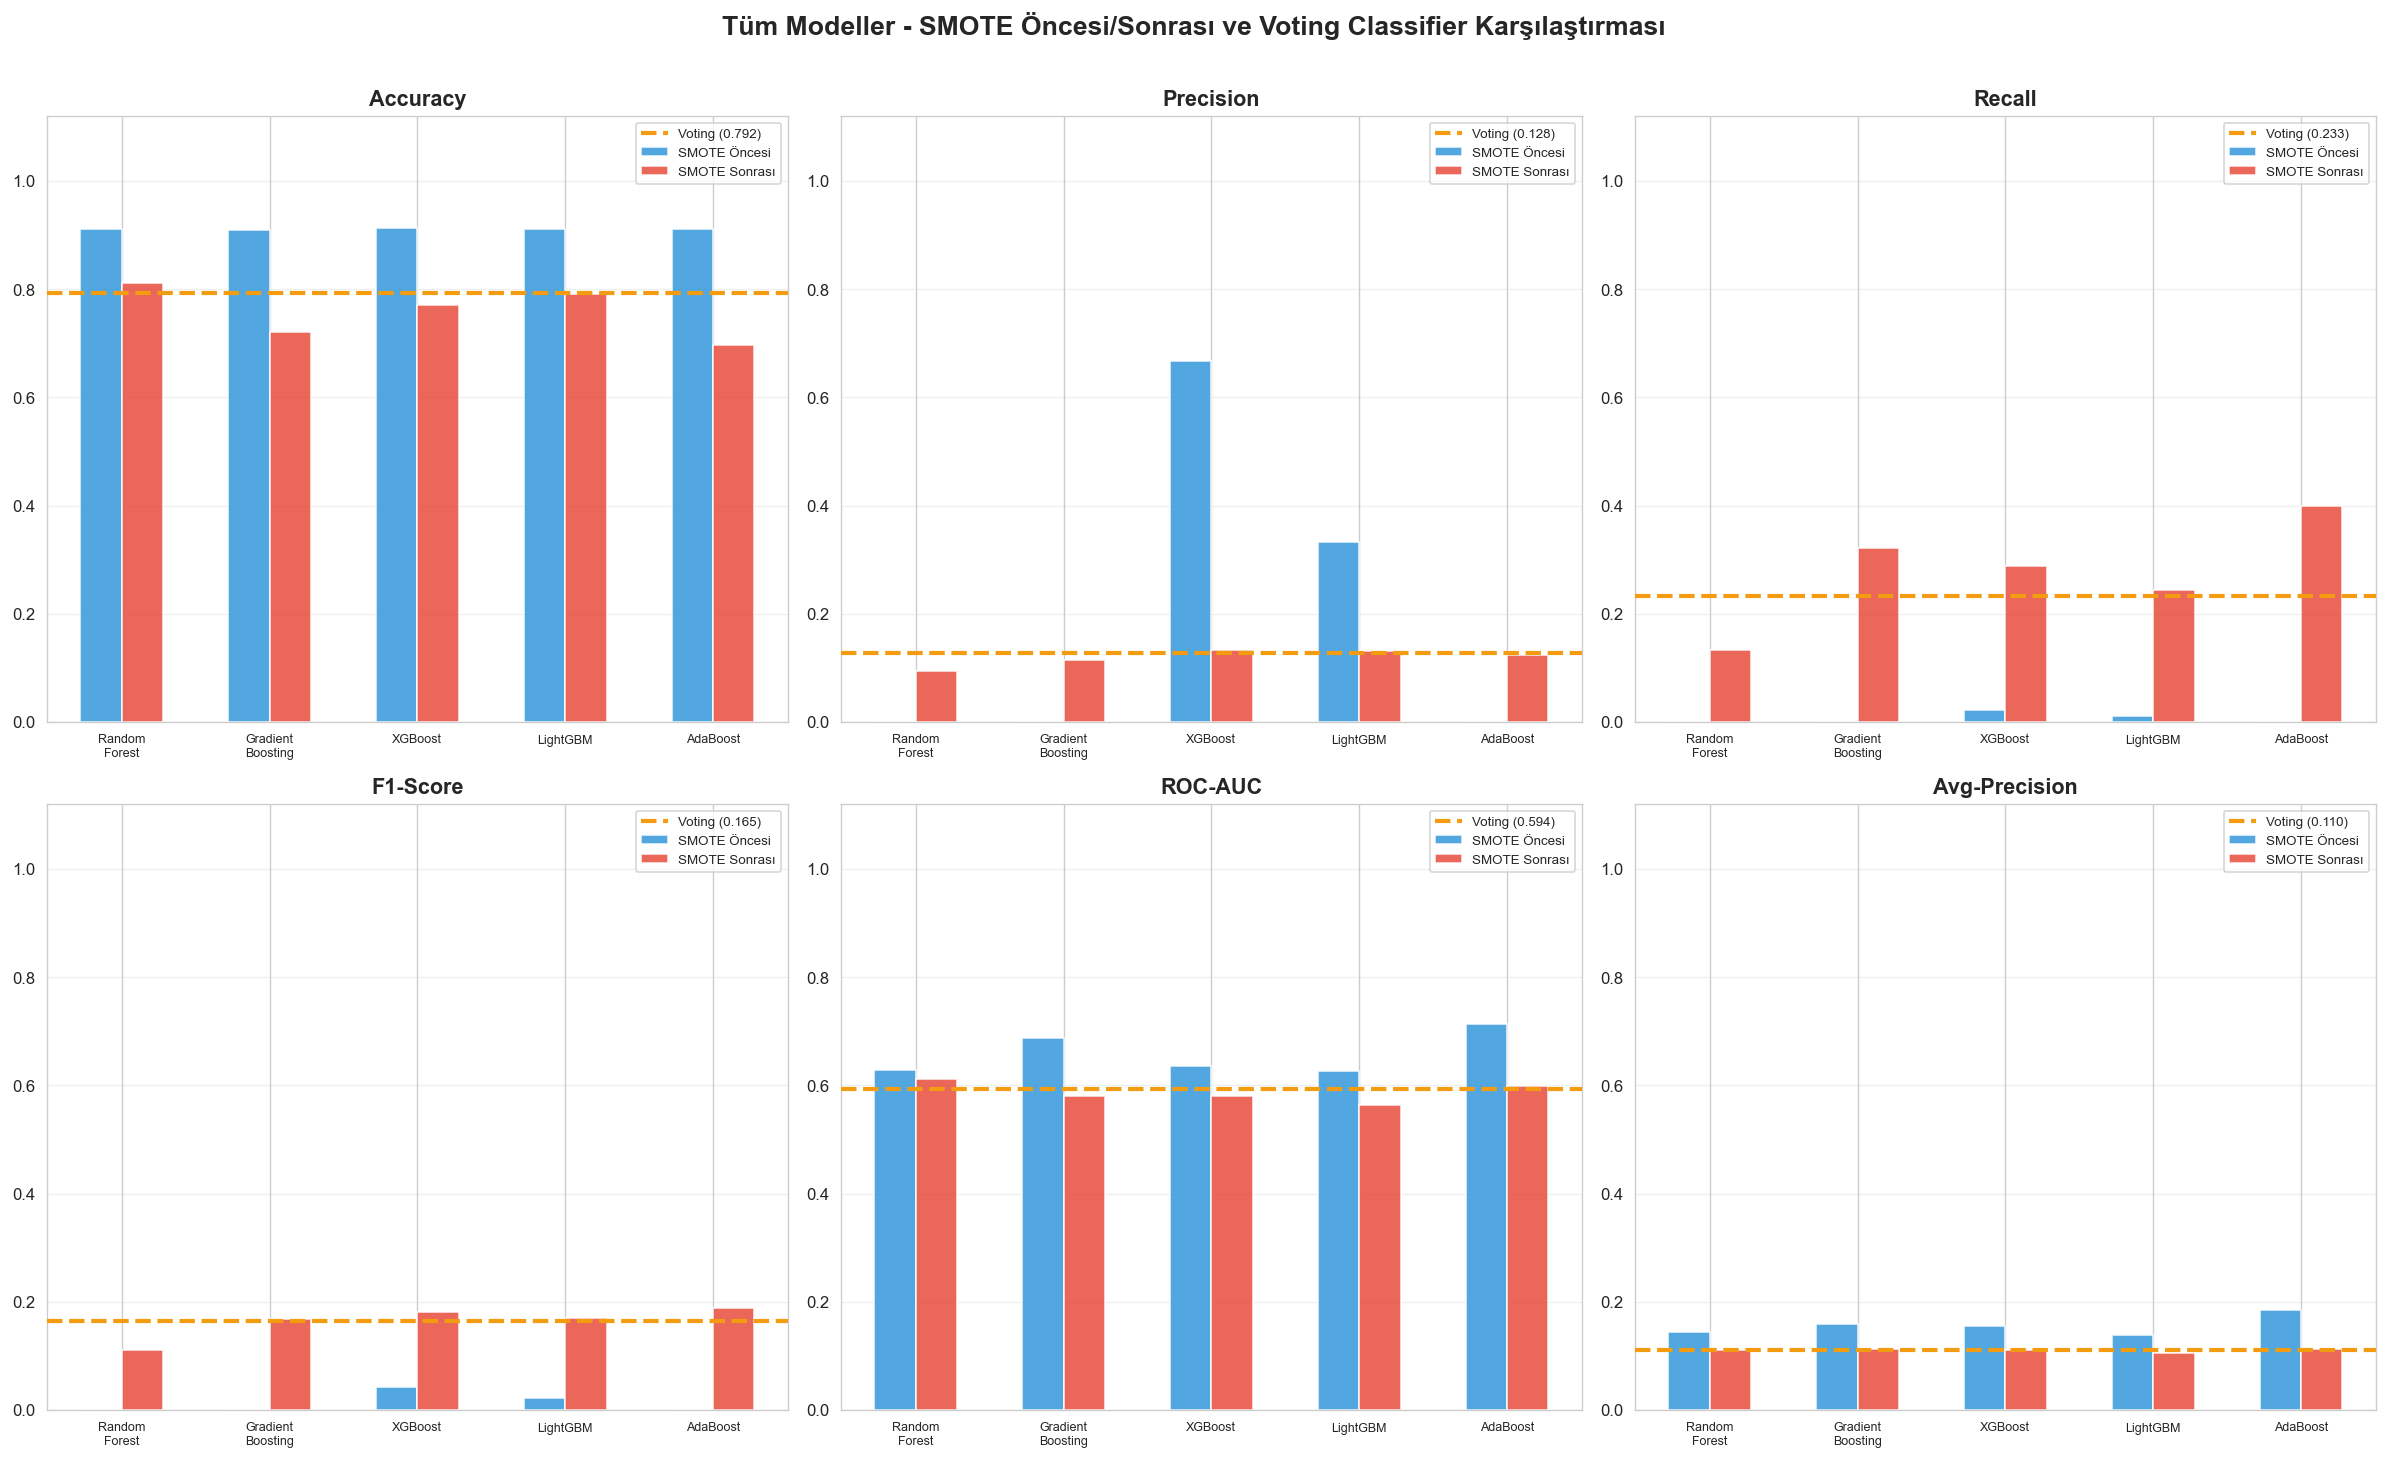

In [29]:
# Tüm sonuçları birleştir
all_models = model_names + ['Voting Classifier\n(RF+XGB+LGBM)']

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

all_metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'Avg-Precision']

for i, metric in enumerate(all_metrics):
    ax = axes[i]
    
    before_vals = df_before[metric].values
    after_vals = df_after[metric].values
    voting_val = voting_results[metric]
    
    x = np.arange(n_models)
    w = 0.28
    
    b1 = ax.bar(x - w, before_vals, w, label='SMOTE Öncesi', color='#3498db', alpha=0.85, edgecolor='white')
    b2 = ax.bar(x, after_vals, w, label='SMOTE Sonrası', color='#e74c3c', alpha=0.85, edgecolor='white')
    ax.axhline(voting_val, color='#f39c12', lw=2.5, linestyle='--',
                label=f'Voting ({voting_val:.3f})', zorder=5)
    
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_xticks(x - w/2)
    ax.set_xticklabels([m.replace(' ', '\n') for m in model_names], fontsize=7.5)
    ax.set_ylim(0, 1.12)
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Tüm Modeller - SMOTE Öncesi/Sonrası ve Voting Classifier Karşılaştırması',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('15_final_karsilastirma.png', bbox_inches='tight', dpi=150)
plt.show()

In [31]:
# Final özet tablo
print('='*90)
print('📊 KAPSAMLI SONUÇ TABLOSU')
print('='*90)

df_before_labeled = df_before.copy()
df_before_labeled['Model'] = df_before_labeled['Model'] + ' (Öncesi)'

df_after_labeled = df_after.copy()
df_after_labeled['Model'] = df_after_labeled['Model'] + ' (Sonrası)'

voting_df = pd.DataFrame([voting_results])
voting_df['Model'] = 'Voting Classifier (Sonrası)'

final_table = pd.concat([df_before_labeled, df_after_labeled, voting_df], ignore_index=True)
final_table = final_table.set_index('Model')
print(final_table.round(4).to_string())

print('\n🏆 EN İYİ SONUÇLAR (SMOTE Sonrası):')
best_f1 = df_after.loc[df_after['F1-Score'].idxmax()]
best_auc = df_after.loc[df_after['ROC-AUC'].idxmax()]
best_recall = df_after.loc[df_after['Recall'].idxmax()]
print(f'  En İyi F1-Score  : {best_f1["Model"]} ({best_f1["F1-Score"]:.4f})')
print(f'  En İyi ROC-AUC   : {best_auc["Model"]} ({best_auc["ROC-AUC"]:.4f})')
print(f'  En İyi Recall    : {best_recall["Model"]} ({best_recall["Recall"]:.4f})')
print(f'  Voting Classifier: F1={voting_results["F1-Score"]:.4f}, AUC={voting_results["ROC-AUC"]:.4f}')

📊 KAPSAMLI SONUÇ TABLOSU
                             Accuracy  Precision  Recall  F1-Score  ROC-AUC  Avg-Precision
Model                                                                                     
Random Forest (Öncesi)         0.9108     0.0000  0.0000    0.0000   0.6286         0.1442
Gradient Boosting (Öncesi)     0.9088     0.0000  0.0000    0.0000   0.6877         0.1584
XGBoost (Öncesi)               0.9127     0.6667  0.0222    0.0430   0.6355         0.1545
LightGBM (Öncesi)              0.9108     0.3333  0.0111    0.0215   0.6260         0.1384
AdaBoost (Öncesi)              0.9118     0.0000  0.0000    0.0000   0.7127         0.1841
Random Forest (Sonrası)        0.8108     0.0945  0.1333    0.1106   0.6124         0.1106
Gradient Boosting (Sonrası)    0.7206     0.1146  0.3222    0.1691   0.5805         0.1135
XGBoost (Sonrası)              0.7706     0.1327  0.2889    0.1818   0.5808         0.1101
LightGBM (Sonrası)             0.7902     0.1310  0.2444    0.170

## 14. Precision-Recall Eğrisi

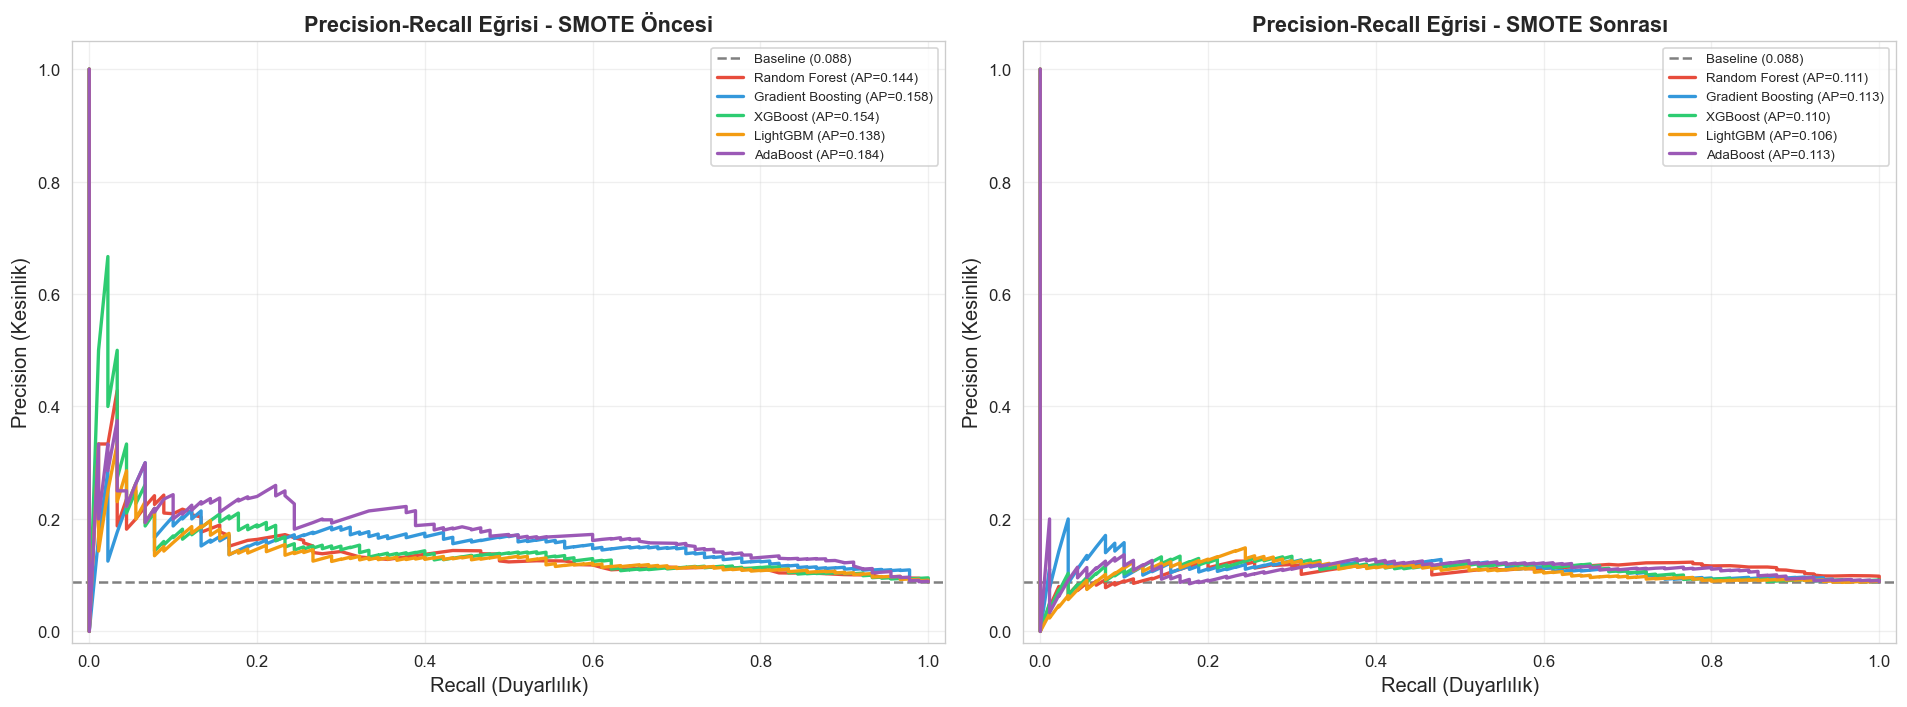

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (title, preds_dict) in zip(axes, [
    ('SMOTE Öncesi', preds_before),
    ('SMOTE Sonrası', preds_after)
]):
    baseline = y_test.mean()
    ax.axhline(baseline, color='gray', linestyle='--', lw=1.5,
                label=f'Baseline ({baseline:.3f})')
    
    for (name, (_, y_prob)), color in zip(preds_dict.items(), colors_roc):
        prec, rec, _ = precision_recall_curve(y_test, y_prob)
        ap = average_precision_score(y_test, y_prob)
        ax.plot(rec, prec, color=color, lw=2, label=f'{name} (AP={ap:.3f})')
    
    ax.set_xlabel('Recall (Duyarlılık)', fontsize=12)
    ax.set_ylabel('Precision (Kesinlik)', fontsize=12)
    ax.set_title(f'Precision-Recall Eğrisi - {title}', fontsize=13, fontweight='bold')
    ax.legend(loc='upper right', fontsize=8)
    ax.set_xlim([-0.02, 1.02])
    ax.set_ylim([-0.02, 1.05])
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('16_pr_curve.png', bbox_inches='tight', dpi=150)
plt.show()

## 15. Çapraz Doğrulama (Cross-Validation)

🔄 5-Fold Çapraz Doğrulama (SMOTE Sonrası)...
Random Forest       : F1 = 0.887 ± 0.008
XGBoost             : F1 = 0.889 ± 0.012
LightGBM            : F1 = 0.871 ± 0.007
Gradient Boosting   : F1 = 0.798 ± 0.011
AdaBoost            : F1 = 0.754 ± 0.009


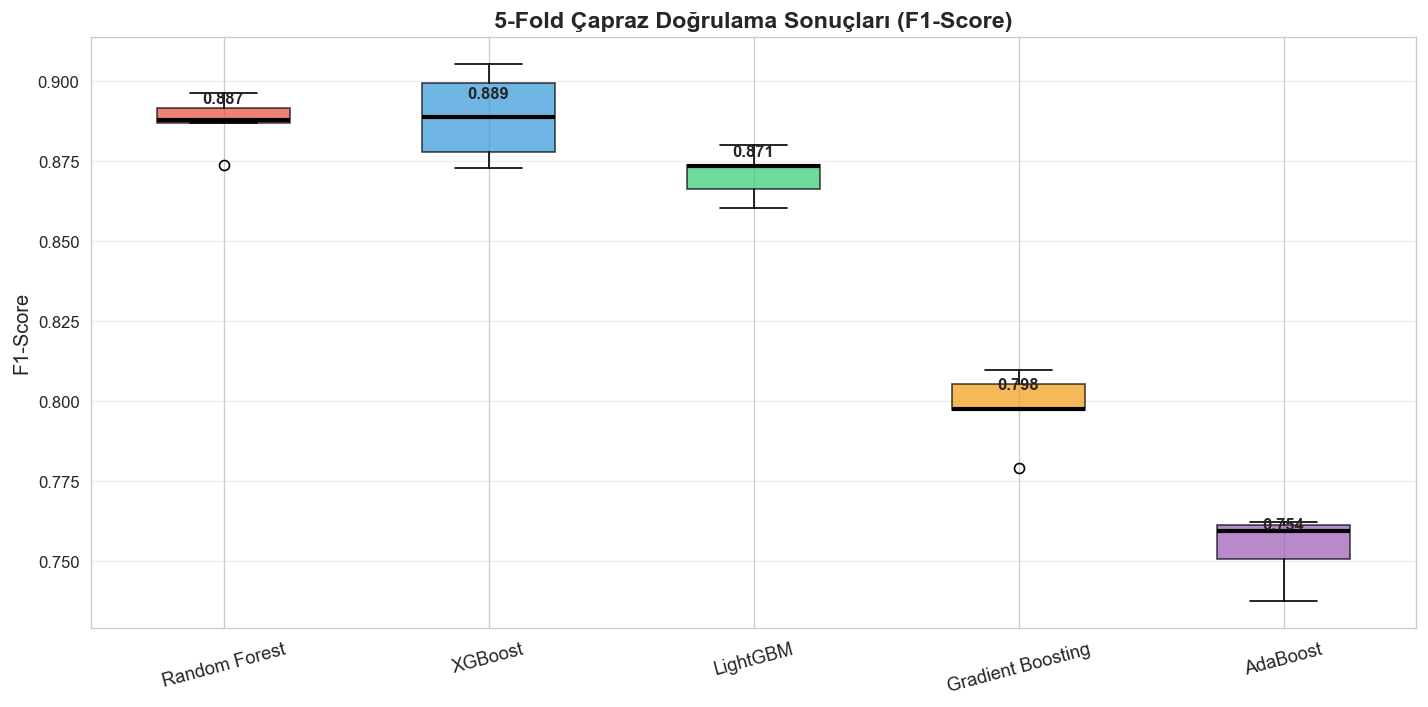

In [33]:
print('🔄 5-Fold Çapraz Doğrulama (SMOTE Sonrası)...')

cv_results = {}
cv_models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=100, eval_metric='logloss',
                              use_label_encoder=False, random_state=42),
    'LightGBM': LGBMClassifier(n_estimators=100, random_state=42, verbose=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in cv_models.items():
    scores = cross_val_score(model, X_train_smote, y_train_smote,
                              cv=cv, scoring='f1', n_jobs=-1)
    cv_results[name] = scores
    print(f'{name:20s}: F1 = {scores.mean():.3f} ± {scores.std():.3f}')

# Görselleştirme
fig, ax = plt.subplots(figsize=(12, 6))
cv_df = pd.DataFrame(cv_results)

bp = ax.boxplot(cv_df.values, patch_artist=True, notch=False,
                 medianprops=dict(color='black', linewidth=2.5))

colors_cv = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']
for patch, color in zip(bp['boxes'], colors_cv):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_xticklabels(cv_df.columns, rotation=15, fontsize=11)
ax.set_ylabel('F1-Score', fontsize=12)
ax.set_title('5-Fold Çapraz Doğrulama Sonuçları (F1-Score)',
              fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Ortalama değerleri ekle
for i, (name, scores) in enumerate(cv_results.items(), 1):
    ax.text(i, scores.mean() + 0.005, f'{scores.mean():.3f}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('17_cross_validation.png', bbox_inches='tight', dpi=150)
plt.show()

## 16. Özellik Önemi Karşılaştırması

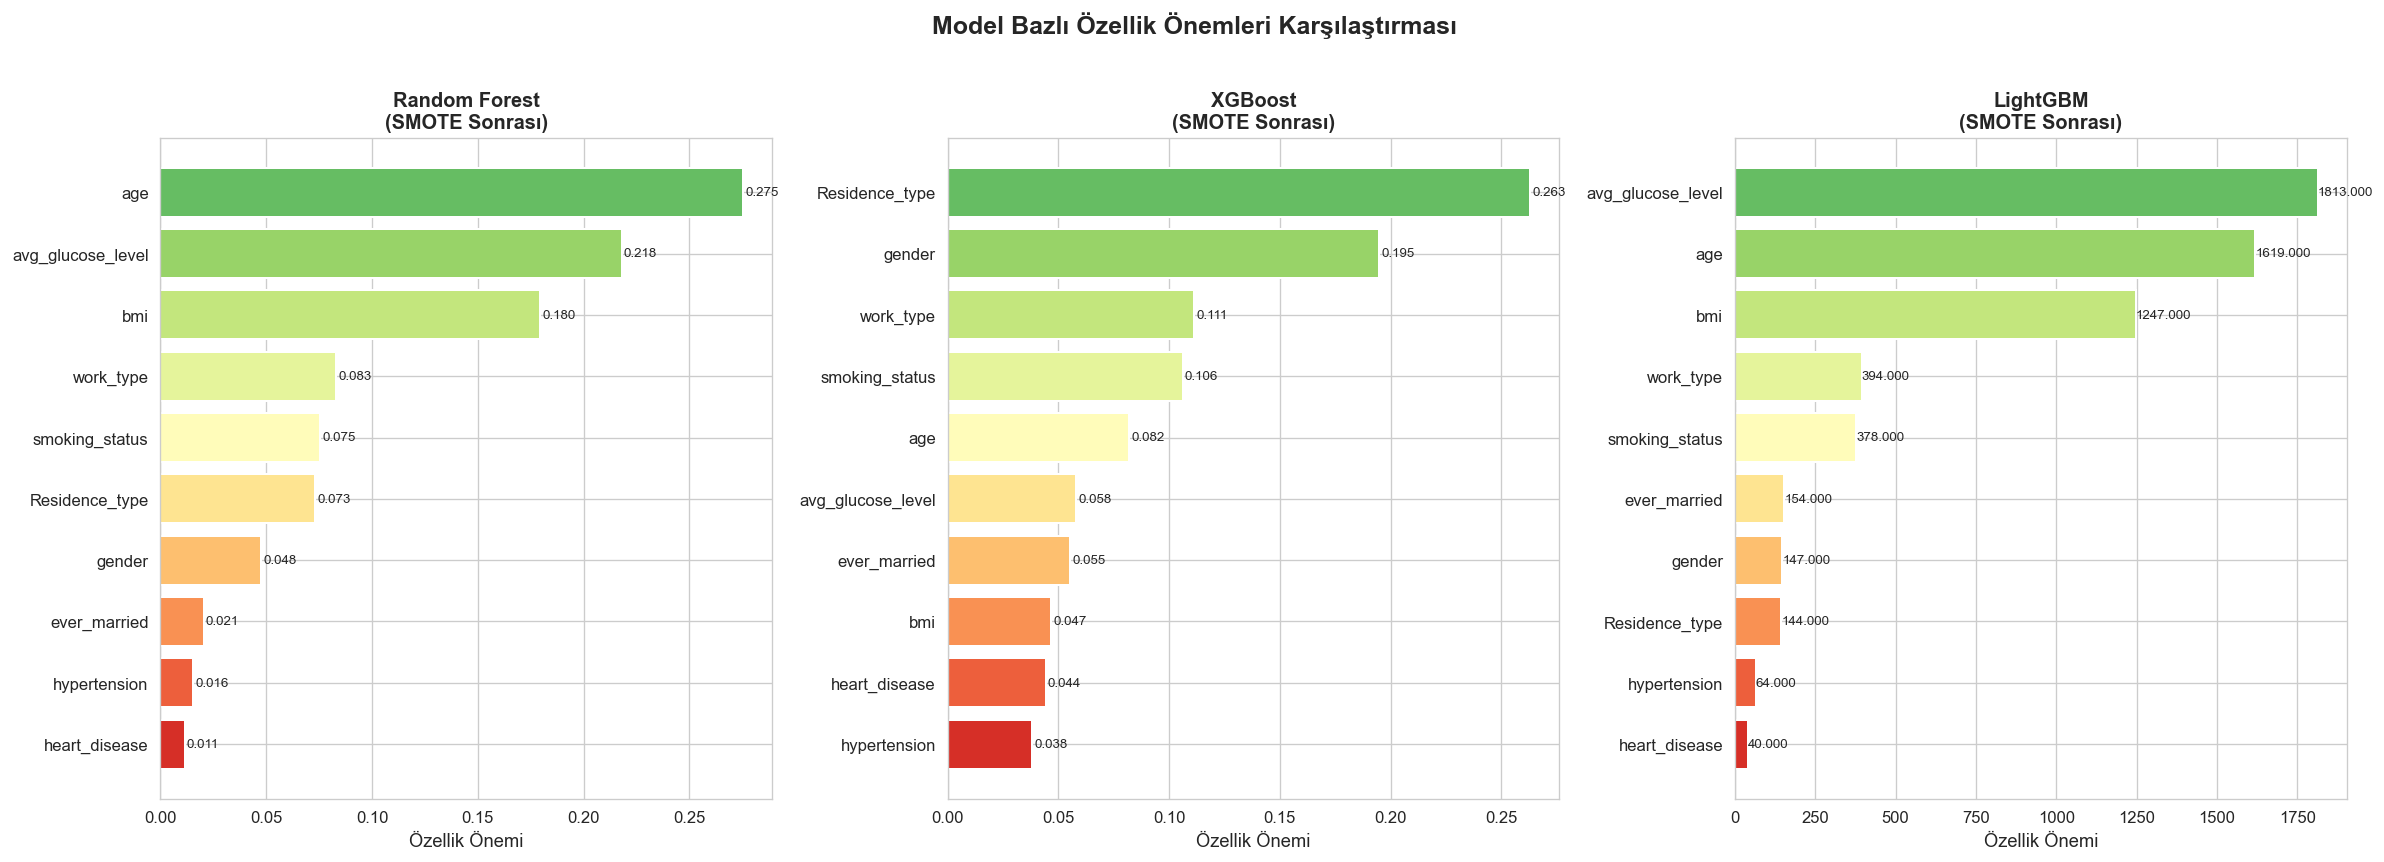

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

feature_models = {
    'Random Forest\n(SMOTE Sonrası)': trained_models_after['Random Forest'],
    'XGBoost\n(SMOTE Sonrası)': trained_models_after['XGBoost'],
    'LightGBM\n(SMOTE Sonrası)': trained_models_after['LightGBM']
}

for ax, (name, model) in zip(axes, feature_models.items()):
    importances = model.feature_importances_
    feat_names = X_test.columns.tolist()
    
    sorted_idx = np.argsort(importances)[::-1]
    top_n = 10
    
    colors_fi = plt.cm.RdYlGn_r(np.linspace(0.2, 0.9, top_n))
    bars = ax.barh(
        range(top_n),
        importances[sorted_idx[:top_n]][::-1],
        color=colors_fi[::-1],
        edgecolor='white', linewidth=1.2
    )
    ax.set_yticks(range(top_n))
    ax.set_yticklabels([feat_names[i] for i in sorted_idx[:top_n]][::-1], fontsize=10)
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xlabel('Özellik Önemi', fontsize=11)
    
    for bar, val in zip(bars, importances[sorted_idx[:top_n]][::-1]):
        ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=8)

plt.suptitle('Model Bazlı Özellik Önemleri Karşılaştırması',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('18_feature_importance.png', bbox_inches='tight', dpi=150)
plt.show()